# Analyse Exploratoire

### Import des modules

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
!wget https://s3.eu-west-1.amazonaws.com/course.oc-static.com/projects/Data_Scientist_P4/2016_Building_Energy_Benchmarking.csv

--2026-09-09 10:50:32--  https://s3.eu-west-1.amazonaws.com/course.oc-static.com/projects/Data_Scientist_P4/2016_Building_Energy_Benchmarking.csv
Resolving s3.eu-west-1.amazonaws.com (s3.eu-west-1.amazonaws.com)... 3.5.72.116, 3.5.72.121, 3.5.66.7, ...
Connecting to s3.eu-west-1.amazonaws.com (s3.eu-west-1.amazonaws.com)|3.5.72.116|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1232057 (1.2M) [text/csv]
Saving to: ‘2016_Building_Energy_Benchmarking.csv’

2016_Building_Energ 100%[===================>]   1.17M  2.44MB/s    in 0.5s    

2026-09-09 10:50:33 (2.44 MB/s) - ‘2016_Building_Energy_Benchmarking.csv’ saved [1232057/1232057]



### Analyse Exploratoire

In [3]:
building_consumption = pd.read_csv("2016_Building_Energy_Benchmarking.csv")

In [4]:
# On regarde comment un batiment est défini dans ce jeu de données
building_consumption.head()

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,...,Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,Comments,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity
0,1,2016,NonResidential,Hotel,Mayflower park hotel,405 Olive way,Seattle,WA,98101.0,0659000030,...,1.156514e+06,3946027.0,12764.52930,1276453.0,False,NaN,Compliant,NaN,249.98,2.83
1,2,2016,NonResidential,Hotel,Paramount Hotel,724 Pine street,Seattle,WA,98101.0,0659000220,...,9.504252e+05,3242851.0,51450.81641,5145082.0,False,NaN,Compliant,NaN,295.86,2.86
2,3,2016,NonResidential,Hotel,5673-The Westin Seattle,1900 5th Avenue,Seattle,WA,98101.0,0659000475,...,1.451544e+07,49526664.0,14938.00000,1493800.0,False,NaN,Compliant,NaN,2089.28,2.19
3,5,2016,NonResidential,Hotel,HOTEL MAX,620 STEWART ST,Seattle,WA,98101.0,0659000640,...,8.115253e+05,2768924.0,18112.13086,1811213.0,False,NaN,Compliant,NaN,286.43,4.67
4,8,2016,NonResidential,Hotel,WARWICK SEATTLE HOTEL (ID8),401 LENORA ST,Seattle,WA,98121.0,0659000970,...,1.573449e+06,5368607.0,88039.98438,8803998.0,False,NaN,Compliant,NaN,505.01,2.88


In [5]:
# On regarde le nombre de valeurs manquantes par colonne ainsi que leur type
building_consumption.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3376 entries, 0 to 3375
Data columns (total 46 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   OSEBuildingID                    3376 non-null   int64  
 1   DataYear                         3376 non-null   int64  
 2   BuildingType                     3376 non-null   object 
 3   PrimaryPropertyType              3376 non-null   object 
 4   PropertyName                     3376 non-null   object 
 5   Address                          3376 non-null   object 
 6   City                             3376 non-null   object 
 7   State                            3376 non-null   object 
 8   ZipCode                          3360 non-null   float64
 9   TaxParcelIdentificationNumber    3376 non-null   object 
 10  CouncilDistrictCode              3376 non-null   int64  
 11  Neighborhood                     3376 non-null   object 
 12  Latitude            

## Glossaire du Dataset : Seattle Building Energy Benchmarking

Ce dataset contient les données de consommation énergétique et les caractéristiques des bâtiments non-résidentiels et multifamiliaux de la ville de Seattle, collectées dans le cadre de leur obligation annuelle de déclaration (benchmarking).

Voici une description claire et concise de ses principales features (colonnes) :

### 📍 1. Identification & Localisation
* **`OSEBuildingID`** : Identifiant unique attribué par le bureau de l'environnement de Seattle (OSE) à chaque propriété pour le suivi.
* **`DataYear`** : Année civile de l'enregistrement des données de consommation.
* **`BuildingName` / `PropertyName`** : Nom usuel ou officiel du bâtiment/de la propriété.
* **`TaxParcelIdentificationNumber`** : Numéro d'identification unique de la parcelle cadastrale (King County PIN).
* **`Address`, `City`, `State`, `ZipCode`** : Adresse postale complète du bâtiment.
* **`Latitude`, `Longitude`** : Coordonnées géographiques de la propriété.
* **`Neighborhood`** : Quartier de la ville où se situe le bâtiment.
* **`CouncilDistrictCode`** : District du conseil municipal dont dépend la propriété.

### 🏢 2. Caractéristiques Structurelles du Bâtiment
* **`BuildingType`** : Catégorisation globale du type de bâtiment (ex : *Multifamily*, *NonResidential*, *Campus*).
* **`PrimaryPropertyType`** : Fonction ou usage principal du bâtiment (ex : *Office*, *Retail Store*, *Hotel*, *Hospital*).
* **`YearBuilt`** : Année de construction du bâtiment.
* **`NumberofBuildings`** : Nombre de bâtiments distincts inclus dans la déclaration de la propriété.
* **`NumberofFloors`** : Nombre d'étages de l'édifice (au-dessus du niveau du sol).

### 📐 3. Surfaces (Gross Floor Area - GFA)
* *Note : Les surfaces sont généralement exprimées en pieds carrés (Square Feet - sf).*
* **`PropertyGFATotal`** : Surface brute totale du bâtiment (incluant les parkings).
* **`PropertyGFAParking`** : Surface brute dédiée au stationnement.
* **`PropertyGFABuilding(s)`** : Surface brute du bâtiment hors parkings (Total GFA - Parking GFA).

### 🏢 4. Répartition des Usages (Property Use Types)
* **`ListOfAllPropertyUseTypes`** : Liste complète des différents usages présents au sein du bâtiment (ex : bureaux, commerces, parkings).
* **`LargestPropertyUseType`** : L'usage qui occupe la plus grande surface dans le bâtiment.
* **`LargestPropertyUseTypeGFA`** : Surface allouée à ce premier usage principal.
* **`SecondLargestPropertyUseType`** / **`SecondLargestPropertyUseTypeGFA`** : Deuxième usage le plus important et sa surface.
* **`ThirdLargestPropertyUseType`** / **`ThirdLargestPropertyUseTypeGFA`** : Troisième usage le plus important et sa surface.

### ⚡ 5. Indicateurs de Performance Énergétique (Métriques EUI)
* *L'EUI (Energy Use Intensity) est la consommation d'énergie divisée par la surface. C'est l'indicateur clé pour comparer des bâtiments de tailles différentes.*
* **`ENERGYSTARScore`** : Note de 1 à 100 évaluant l'efficacité énergétique par rapport à des bâtiments similaires au niveau national (100 = très performant).
* **`SiteEUI(kBtu/sf)`** : Intensité énergétique réelle consommée sur place (sur le "site").
* **`SiteEUIWN(kBtu/sf)`** : Site EUI *Weather Normalized* (ajusté pour lisser les variations météorologiques annuelles, ex : hivers particulièrement froids).
* **`SourceEUI(kBtu/sf)`** : Intensité énergétique à la "source" (inclut l'énergie consommée sur site + les pertes dues à la production et la distribution d'énergie).
* **`SourceEUIWN(kBtu/sf)`** : Source EUI ajusté selon la météo.

### 🛢️ 6. Consommations Totales par Type d'Énergie
* **`SiteEnergyUse(kBtu)`** : Quantité totale d'énergie consommée par le bâtiment sur l'année.
* **`SiteEnergyUseWN(kBtu)`** : Consommation totale ajustée selon la météo.
* **`SteamUse(kBtu)`** : Quantité de vapeur consommée (via réseau de chaleur urbain).
* **`Electricity(kWh)`** / **`Electricity(kBtu)`** : Consommation électrique annuelle (exprimée en kilowattheures ou convertie en kilo-BTU).
* **`NaturalGas(therms)`** / **`NaturalGas(kBtu)`** : Consommation de gaz naturel.
* **`OtherFuelUse(kBtu)`** : Consommation d'autres carburants/combustibles (fioul, etc.).

### 🌍 7. Émissions de Gaz à Effet de Serre (GES)
* **`GHGEmissions(MetricTonsCO2e)`** : Émissions totales annuelles de gaz à effet de serre du bâtiment (en tonnes d'équivalent CO2).
* **`GHGEmissionsIntensity(kgCO2e/ft2)`** : Intensité des émissions de GES rapportée à la surface du bâtiment (kilos de CO2 par pied carré).

### 📋 8. Informations Administratives
* **`ComplianceStatus`** : Indique si le propriétaire a respecté l'obligation de déclaration (ex : *Compliant*, *Non-Compliant*, *Missing Data*).
* **`DefaultData`** : Booléen ou indicateur signalant si le déclarant a utilisé des valeurs par défaut au lieu de données réelles pour certaines caractéristiques.

## Filtrage

### F1 - No variance

In [6]:
# F1 = Premier filtre sur les features sans variances --> Masquage sur les colonnes à une seule valeur unique
df_F1 = building_consumption.filter(items=building_consumption.columns[building_consumption.nunique() > 1])
df_F1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3376 entries, 0 to 3375
Data columns (total 42 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   OSEBuildingID                    3376 non-null   int64  
 1   BuildingType                     3376 non-null   object 
 2   PrimaryPropertyType              3376 non-null   object 
 3   PropertyName                     3376 non-null   object 
 4   Address                          3376 non-null   object 
 5   ZipCode                          3360 non-null   float64
 6   TaxParcelIdentificationNumber    3376 non-null   object 
 7   CouncilDistrictCode              3376 non-null   int64  
 8   Neighborhood                     3376 non-null   object 
 9   Latitude                         3376 non-null   float64
 10  Longitude                        3376 non-null   float64
 11  YearBuilt                        3376 non-null   int64  
 12  NumberofBuildings   

### F2 Filtre valeurs nulles --> Colonnes

In [7]:
# F2 = Deuxieme filtre sur les valeurs nulles --> Masquage de colonnes.
# Calculer le ratio de valeurs manquantes par colonne (entre 0.0 et 1.0)
pourcentage_nan = df_F1.isnull().mean()
print(pourcentage_nan[pourcentage_nan > 0.10]*100)
colonnes_a_garder = pourcentage_nan[pourcentage_nan <= 0.20].index
print(colonnes_a_garder)
df_F2= df_F1[colonnes_a_garder]
print(df_F2.info())
pourcentage_nan = df_F2.isnull().mean()
print(pourcentage_nan[pourcentage_nan > 0])

SecondLargestPropertyUseType       50.266588
SecondLargestPropertyUseTypeGFA    50.266588
ThirdLargestPropertyUseType        82.345972
ThirdLargestPropertyUseTypeGFA     82.345972
YearsENERGYSTARCertified           96.475118
ENERGYSTARScore                    24.970379
Outlier                            99.052133
dtype: float64
Index(['OSEBuildingID', 'BuildingType', 'PrimaryPropertyType', 'PropertyName',
       'Address', 'ZipCode', 'TaxParcelIdentificationNumber',
       'CouncilDistrictCode', 'Neighborhood', 'Latitude', 'Longitude',
       'YearBuilt', 'NumberofBuildings', 'NumberofFloors', 'PropertyGFATotal',
       'PropertyGFAParking', 'PropertyGFABuilding(s)',
       'ListOfAllPropertyUseTypes', 'LargestPropertyUseType',
       'LargestPropertyUseTypeGFA', 'SiteEUI(kBtu/sf)', 'SiteEUIWN(kBtu/sf)',
       'SourceEUI(kBtu/sf)', 'SourceEUIWN(kBtu/sf)', 'SiteEnergyUse(kBtu)',
       'SiteEnergyUseWN(kBtu)', 'SteamUse(kBtu)', 'Electricity(kWh)',
       'Electricity(kBtu)', 'NaturalGa

### F3 Filtre valeurs nulles --> lignes

In [8]:
# F3 : troisième filtre sur les valeurs nulles --> Drop sur les lignes
df_F3 = df_F2.dropna(axis=0)
print(df_F3.info())

<class 'pandas.core.frame.DataFrame'>
Index: 3337 entries, 0 to 3359
Data columns (total 35 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   OSEBuildingID                  3337 non-null   int64  
 1   BuildingType                   3337 non-null   object 
 2   PrimaryPropertyType            3337 non-null   object 
 3   PropertyName                   3337 non-null   object 
 4   Address                        3337 non-null   object 
 5   ZipCode                        3337 non-null   float64
 6   TaxParcelIdentificationNumber  3337 non-null   object 
 7   CouncilDistrictCode            3337 non-null   int64  
 8   Neighborhood                   3337 non-null   object 
 9   Latitude                       3337 non-null   float64
 10  Longitude                      3337 non-null   float64
 11  YearBuilt                      3337 non-null   int64  
 12  NumberofBuildings              3337 non-null   float6

### F4 Filtre sur les features PII/metadata

In [9]:
# F4 : quatrième filtre sur les features à caractère d'identification/PII, Metadata
pii_columns=['OSEBuildingID','PropertyName', 'Address', 'TaxParcelIdentificationNumber', 'ZipCode', 'ListOfAllPropertyUseTypes', 'ComplianceStatus']
df_F4= df_F3.drop(columns=pii_columns)
print(df_F4.info())

<class 'pandas.core.frame.DataFrame'>
Index: 3337 entries, 0 to 3359
Data columns (total 28 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   BuildingType               3337 non-null   object 
 1   PrimaryPropertyType        3337 non-null   object 
 2   CouncilDistrictCode        3337 non-null   int64  
 3   Neighborhood               3337 non-null   object 
 4   Latitude                   3337 non-null   float64
 5   Longitude                  3337 non-null   float64
 6   YearBuilt                  3337 non-null   int64  
 7   NumberofBuildings          3337 non-null   float64
 8   NumberofFloors             3337 non-null   int64  
 9   PropertyGFATotal           3337 non-null   int64  
 10  PropertyGFAParking         3337 non-null   int64  
 11  PropertyGFABuilding(s)     3337 non-null   int64  
 12  LargestPropertyUseType     3337 non-null   object 
 13  LargestPropertyUseTypeGFA  3337 non-null   float64
 1

### F5 Filtre sur les features target / Data Leakage

In [10]:
# F5 : cinquième filtre sur les features target / Data Leakage
# y = ['TotalGHGEmissions'] # On consèrve la variable que l'on veut prédire/target. Pour l'EDA, elle sera séparé à la modélisation
data_leakage_columns = [
    'GHGEmissionsIntensity', 'SourceEUIWN(kBtu/sf)',
    'SiteEUI(kBtu/sf)', 'SiteEUIWN(kBtu/sf)', 'SourceEUI(kBtu/sf)',
    'SiteEnergyUse(kBtu)', 'SiteEnergyUseWN(kBtu)', 'SteamUse(kBtu)',
    'Electricity(kWh)', 'Electricity(kBtu)', 'NaturalGas(therms)', 'NaturalGas(kBtu)',
]
df_F5= df_F4.drop(columns=data_leakage_columns)
print(df_F5.info())

<class 'pandas.core.frame.DataFrame'>
Index: 3337 entries, 0 to 3359
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   BuildingType               3337 non-null   object 
 1   PrimaryPropertyType        3337 non-null   object 
 2   CouncilDistrictCode        3337 non-null   int64  
 3   Neighborhood               3337 non-null   object 
 4   Latitude                   3337 non-null   float64
 5   Longitude                  3337 non-null   float64
 6   YearBuilt                  3337 non-null   int64  
 7   NumberofBuildings          3337 non-null   float64
 8   NumberofFloors             3337 non-null   int64  
 9   PropertyGFATotal           3337 non-null   int64  
 10  PropertyGFAParking         3337 non-null   int64  
 11  PropertyGFABuilding(s)     3337 non-null   int64  
 12  LargestPropertyUseType     3337 non-null   object 
 13  LargestPropertyUseTypeGFA  3337 non-null   float64
 1

 ### F6 Filtre sur la colinéarité

In [11]:
# F6 : Filtrage sur la colinéarité
df_F6 = df_F5.drop(columns=['PropertyGFATotal'])
print(df_F6.info())

<class 'pandas.core.frame.DataFrame'>
Index: 3337 entries, 0 to 3359
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   BuildingType               3337 non-null   object 
 1   PrimaryPropertyType        3337 non-null   object 
 2   CouncilDistrictCode        3337 non-null   int64  
 3   Neighborhood               3337 non-null   object 
 4   Latitude                   3337 non-null   float64
 5   Longitude                  3337 non-null   float64
 6   YearBuilt                  3337 non-null   int64  
 7   NumberofBuildings          3337 non-null   float64
 8   NumberofFloors             3337 non-null   int64  
 9   PropertyGFAParking         3337 non-null   int64  
 10  PropertyGFABuilding(s)     3337 non-null   int64  
 11  LargestPropertyUseType     3337 non-null   object 
 12  LargestPropertyUseTypeGFA  3337 non-null   float64
 13  DefaultData                3337 non-null   bool   
 1

### F7 Filtre sur les outliers

In [12]:
# F7 : Filtrage sur les outliers
df_F6.describe()

,CouncilDistrictCode,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFAParking,PropertyGFABuilding(s),LargestPropertyUseTypeGFA,TotalGHGEmissions
count,3337.000000,3337.000000,3337.000000,3337.000000,3337.000000,3337.000000,3337.000000,3.337000e+03,3.337000e+03,3337.000000
mean,4.440515,47.623964,-122.334779,1968.529218,1.107582,4.724903,8063.891819,8.702749e+04,7.919874e+04,120.249811
std,2.120786,0.047663,0.027136,33.118381,2.118095,5.513105,32475.541333,2.078021e+05,2.014896e+05,541.145903
min,1.000000,47.499170,-122.414250,1900.000000,0.000000,0.000000,0.000000,3.636000e+03,5.656000e+03,-0.800000
25%,3.000000,47.599870,-122.350440,1948.000000,1.000000,2.000000,0.000000,2.791000e+04,2.520000e+04,9.510000
50%,4.000000,47.618660,-122.332500,1974.000000,1.000000,4.000000,0.000000,4.338700e+04,4.000000e+04,34.080000
75%,7.000000,47.656980,-122.319545,1997.000000,1.000000,5.000000,0.000000,8.475000e+04,7.663100e+04,94.020000
max,7.000000,47.733870,-122.220966,2015.000000,111.000000,99.000000,512608.000000,9.320156e+06,9.320156e+06,16870.980000


In [13]:
seuil_99 = df_F6['TotalGHGEmissions'].quantile(0.99)
# 2. Filtrer les valeurs aberrantes en haut (<= seuil_90) ET en bas (>= 0)
df_F7 = df_F6[
    (df_F6['TotalGHGEmissions'] > 0) &
    (df_F6['TotalGHGEmissions'] <= seuil_99)
]
df_clean = df_F7
print(df_clean.describe())
print(df_clean.info())

       CouncilDistrictCode     Latitude    Longitude    YearBuilt  \
count          3295.000000  3295.000000  3295.000000  3295.000000   
mean              4.436115    47.623950  -122.334837  1968.521093   
std               2.122701     0.047776     0.027208    33.125272   
min               1.000000    47.499170  -122.414250  1900.000000   
25%               3.000000    47.599790  -122.350705  1948.000000   
50%               4.000000    47.618850  -122.332610  1974.000000   
75%               7.000000    47.657095  -122.319522  1997.000000   
max               7.000000    47.733870  -122.220966  2015.000000   

       NumberofBuildings  NumberofFloors  PropertyGFAParking  \
count        3295.000000     3295.000000         3295.000000   
mean            1.061912        4.671017         7984.660698   
std             0.873507        5.422507        32322.955102   
min             0.000000        0.000000            0.000000   
25%             1.000000        2.000000            0.0000

## Etude graphique

### Etude graphique des variables numériques

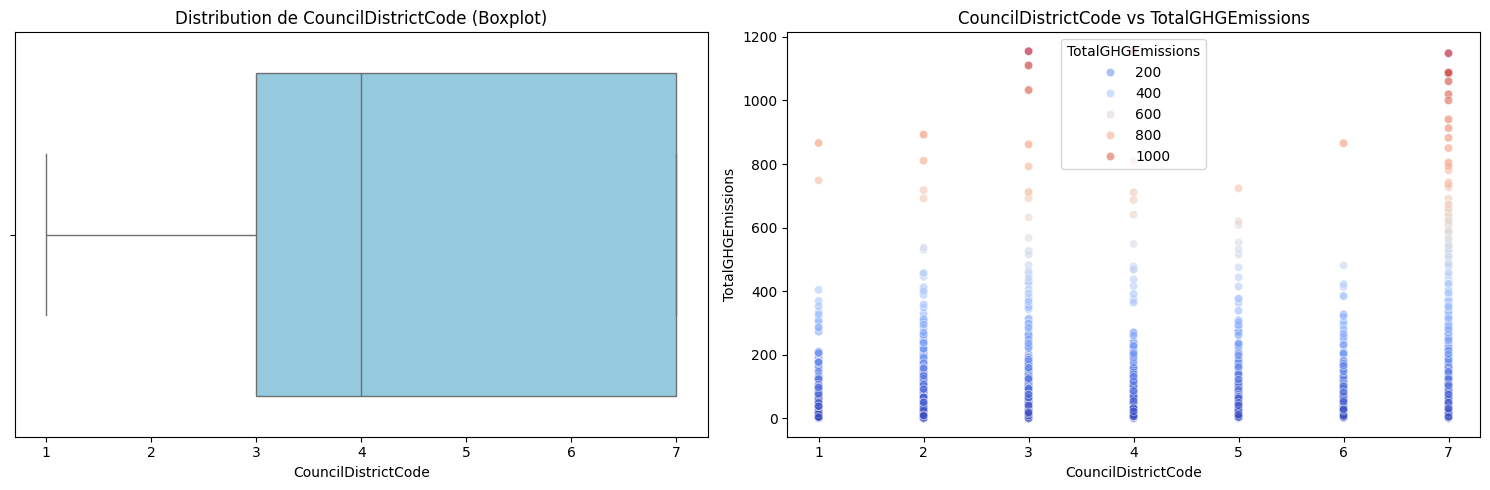

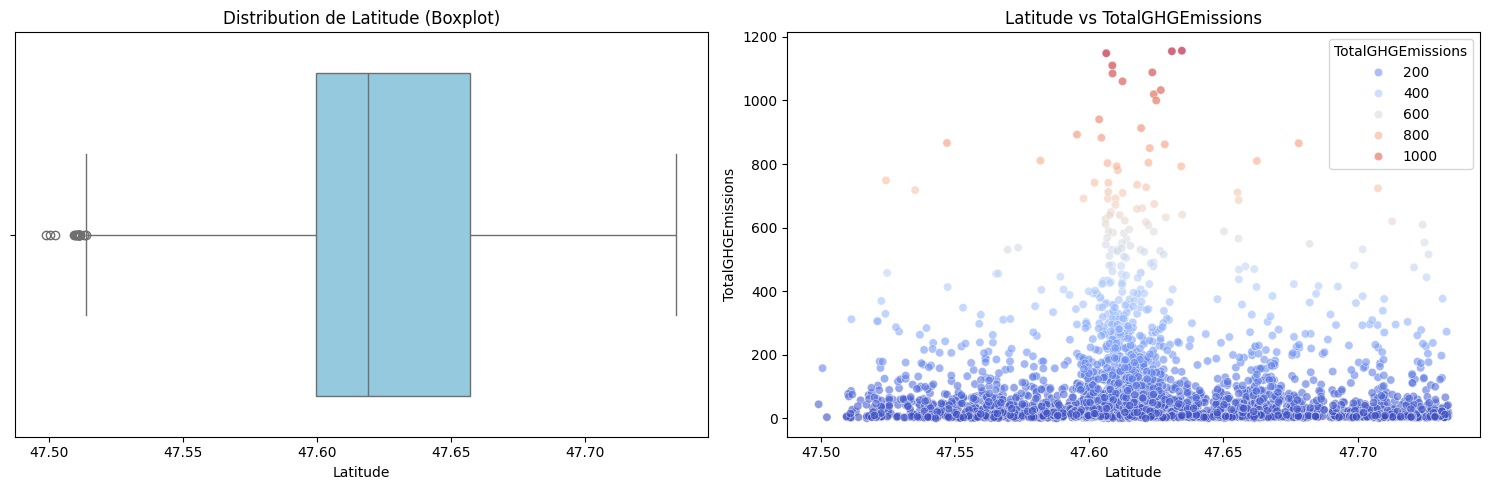

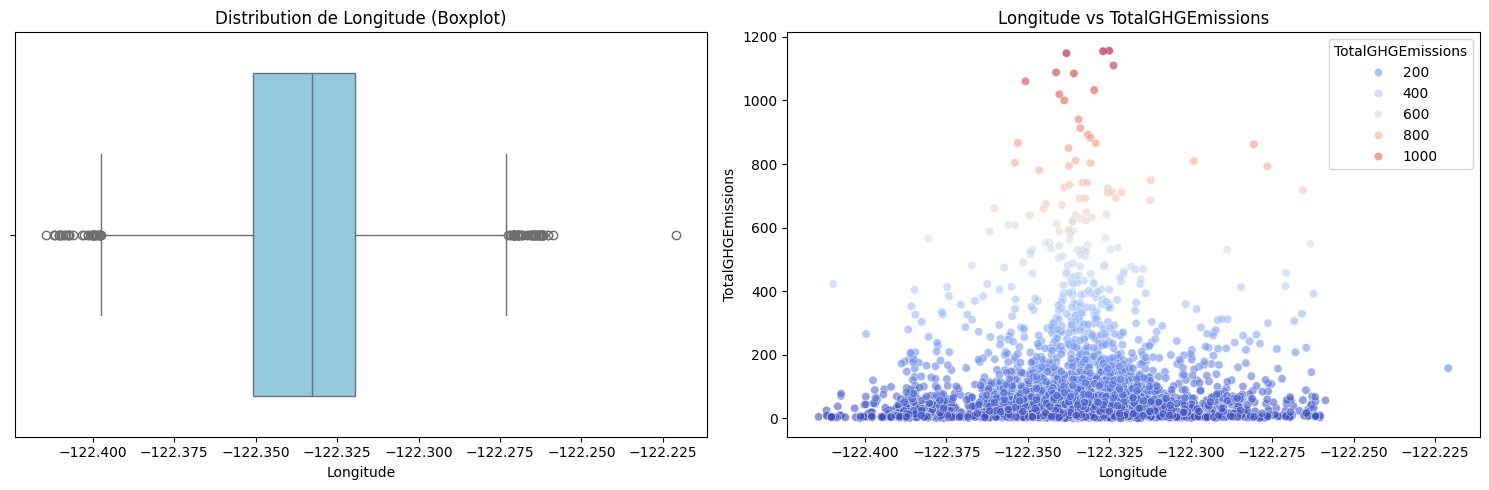

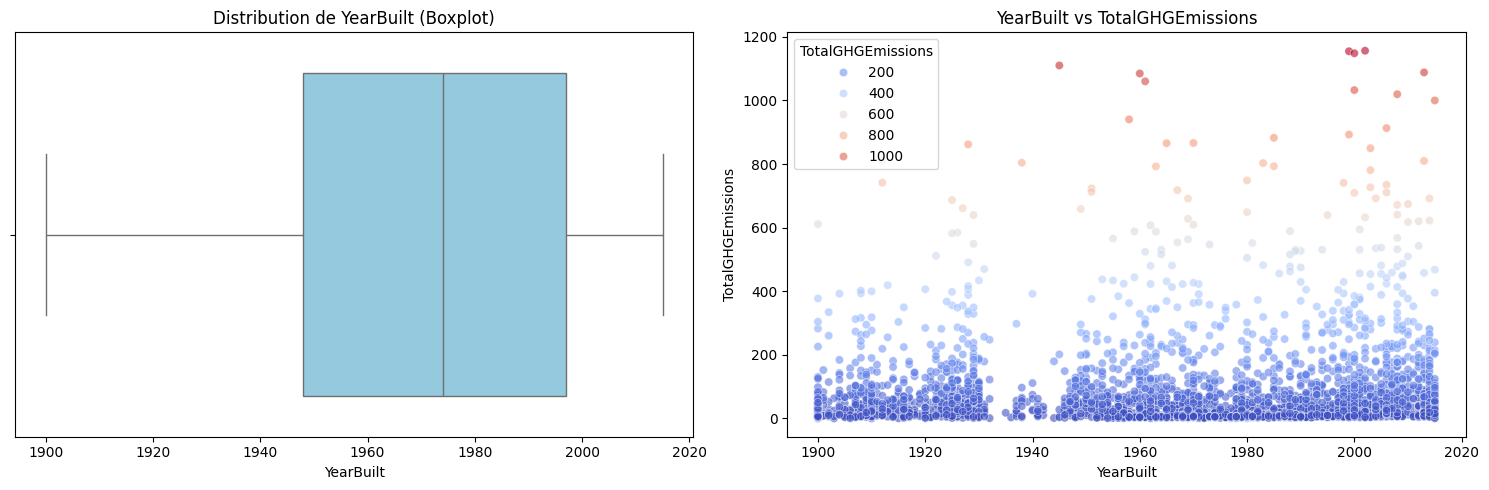

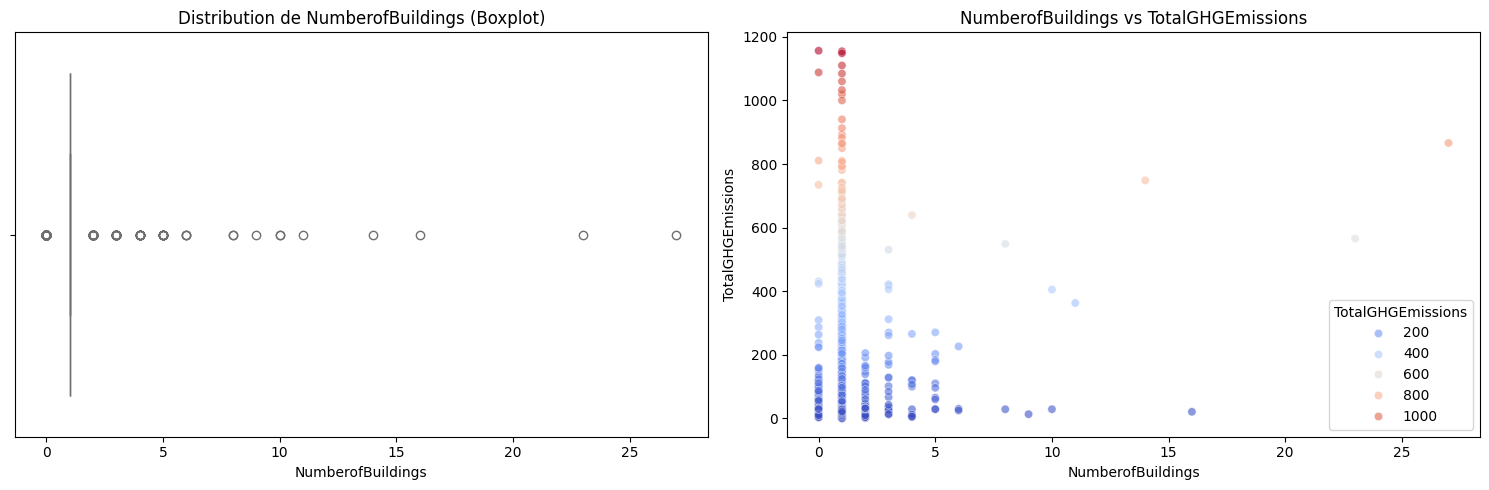

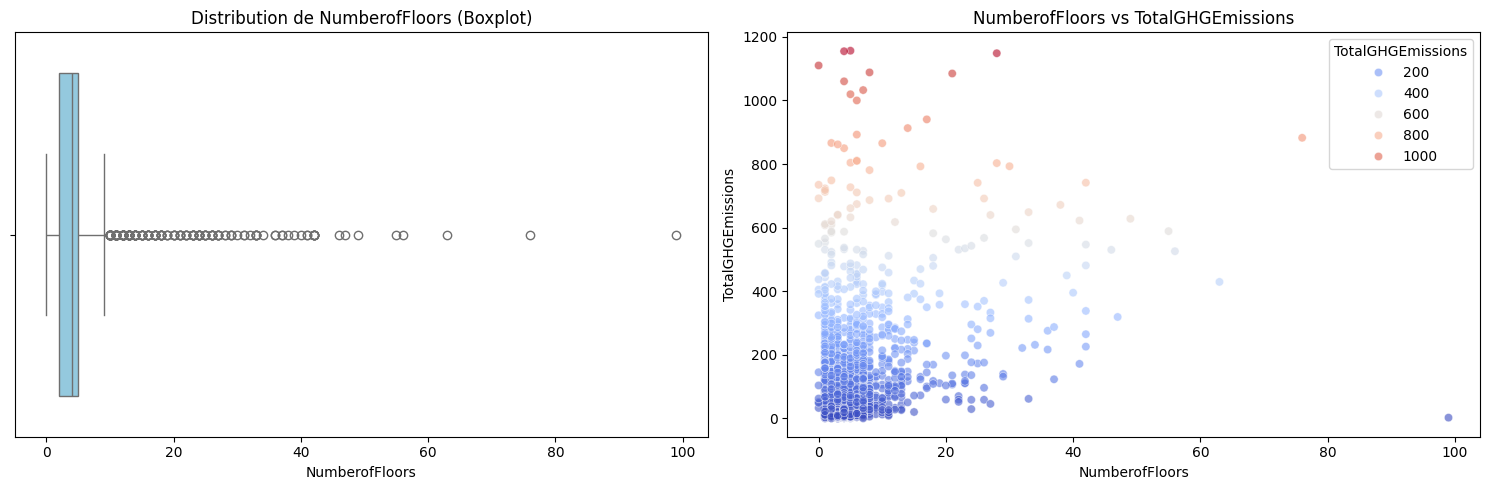

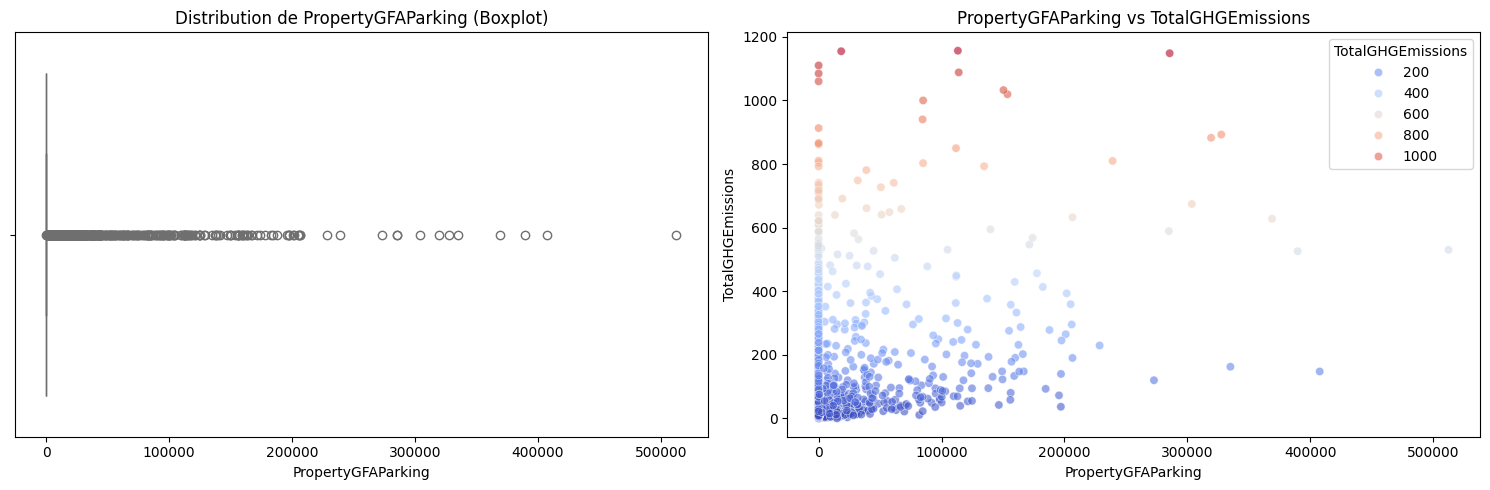

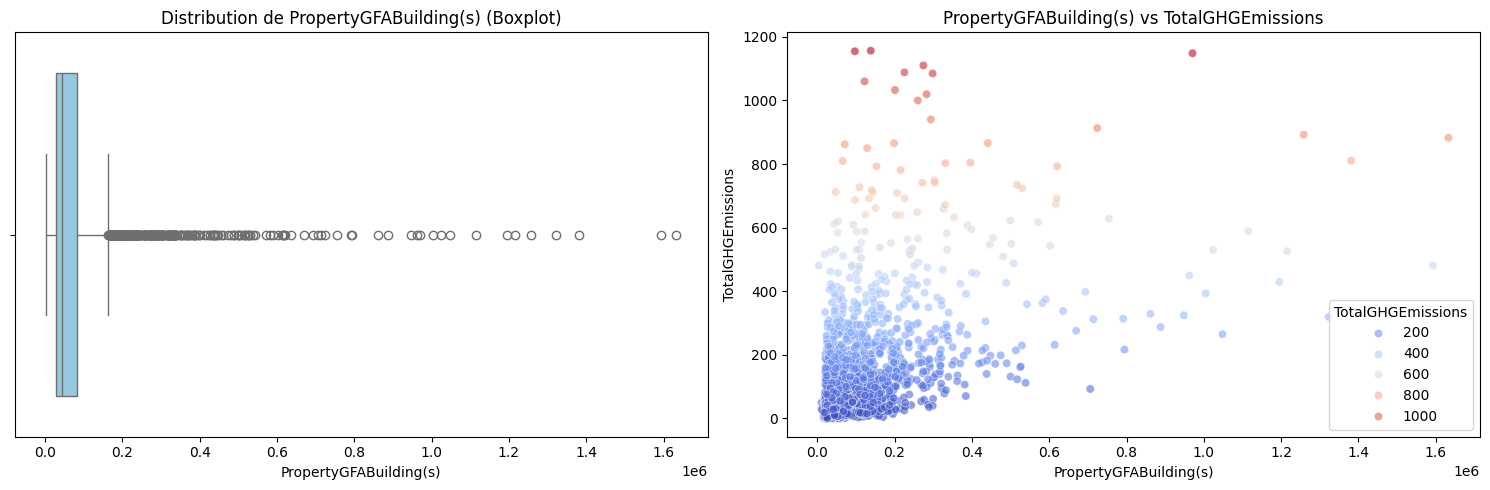

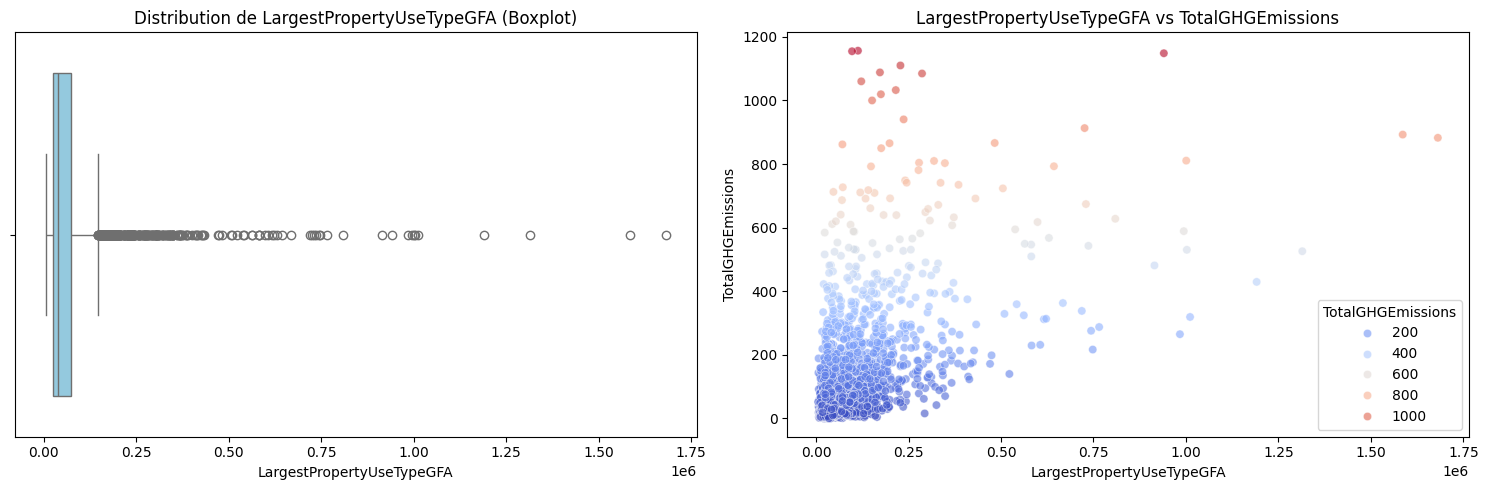

In [14]:
# 1. Identifier les colonnes numériques (Features)
# On exclut la Target de la boucle pour ne pas la tracer contre elle-même
df_num = df_clean.select_dtypes(include=['int64', 'float64'])
target_col = 'TotalGHGEmissions'
features_num = [col for col in df_num.columns if col != target_col]

# 2. Boucle sur chaque feature numérique
for feature in features_num:
    # Création d'une figure avec 2 sous-graphiques (1 ligne, 2 colonnes)
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # --- GRAPHIQUE 1 : Le Boxplot (à gauche) ---
    sns.boxplot(
        data=df_clean,
        x=feature,
        ax=axes[0],
        color='skyblue'
    )
    axes[0].set_title(f'Distribution de {feature} (Boxplot)')

    # --- GRAPHIQUE 2 : Le Scatter Plot (à droite) ---
    sns.scatterplot(
        data=df_clean,
        x=feature,
        y=target_col, # La target est toujours sur l'axe Y
        hue=target_col, # Coloration selon la target
        palette='coolwarm',
        ax=axes[1],
        alpha=0.6 # Rend les points un peu transparents pour mieux voir la densité
    )
    axes[1].set_title(f'{feature} vs {target_col}')

    # Ajustement de l'espacement et affichage
    plt.tight_layout()

In [15]:
# Calculer le coefficient d'asymétrie pour toutes les variables numériques
asymetrie = df_clean.select_dtypes(include=['float64', 'int64']).skew()

# Afficher les variables qui dépassent le seuil critique de 1
print(asymetrie[asymetrie > 1].sort_values(ascending=False))

NumberofBuildings            17.509755
PropertyGFAParking            6.713013
LargestPropertyUseTypeGFA     6.208770
NumberofFloors                6.114479
PropertyGFABuilding(s)        5.845735
TotalGHGEmissions             3.516045
dtype: float64


### Etude graphique des variables catégorielles

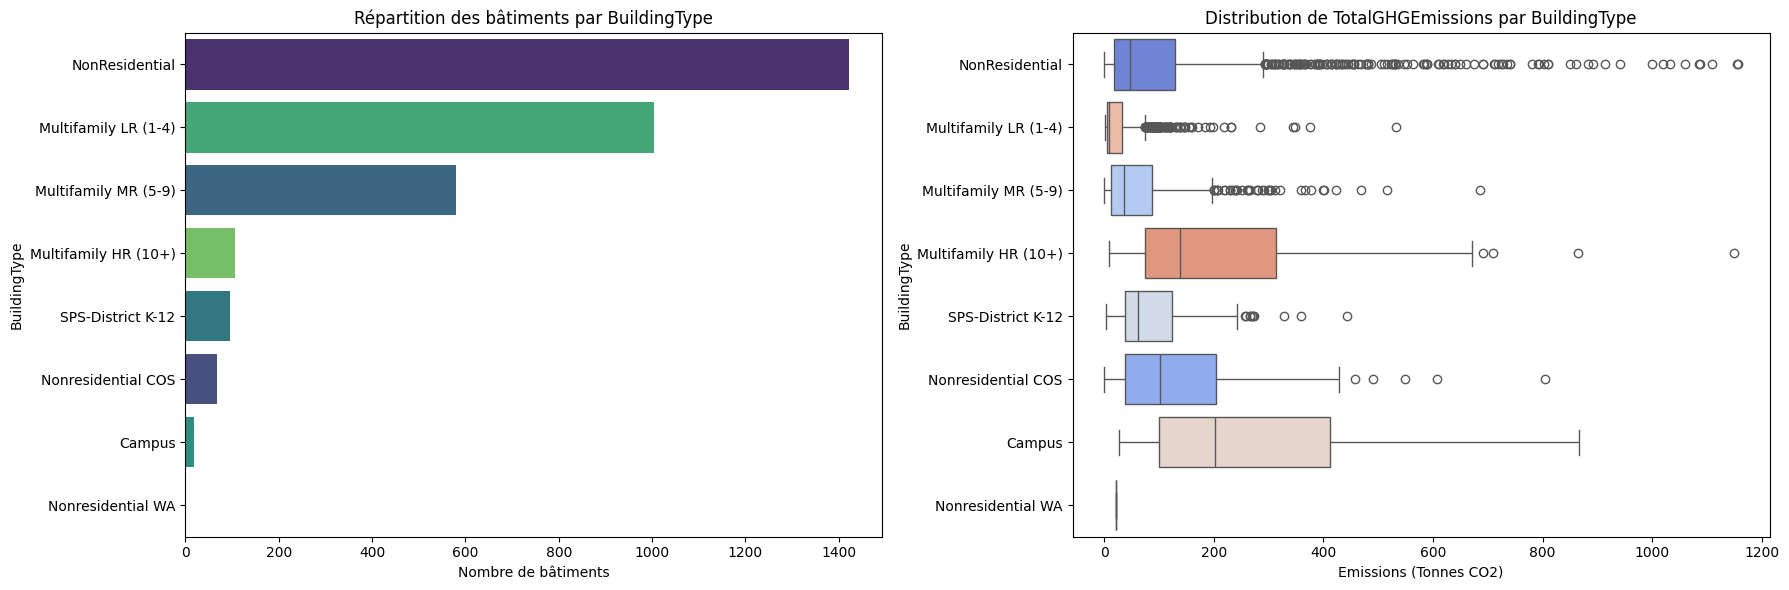

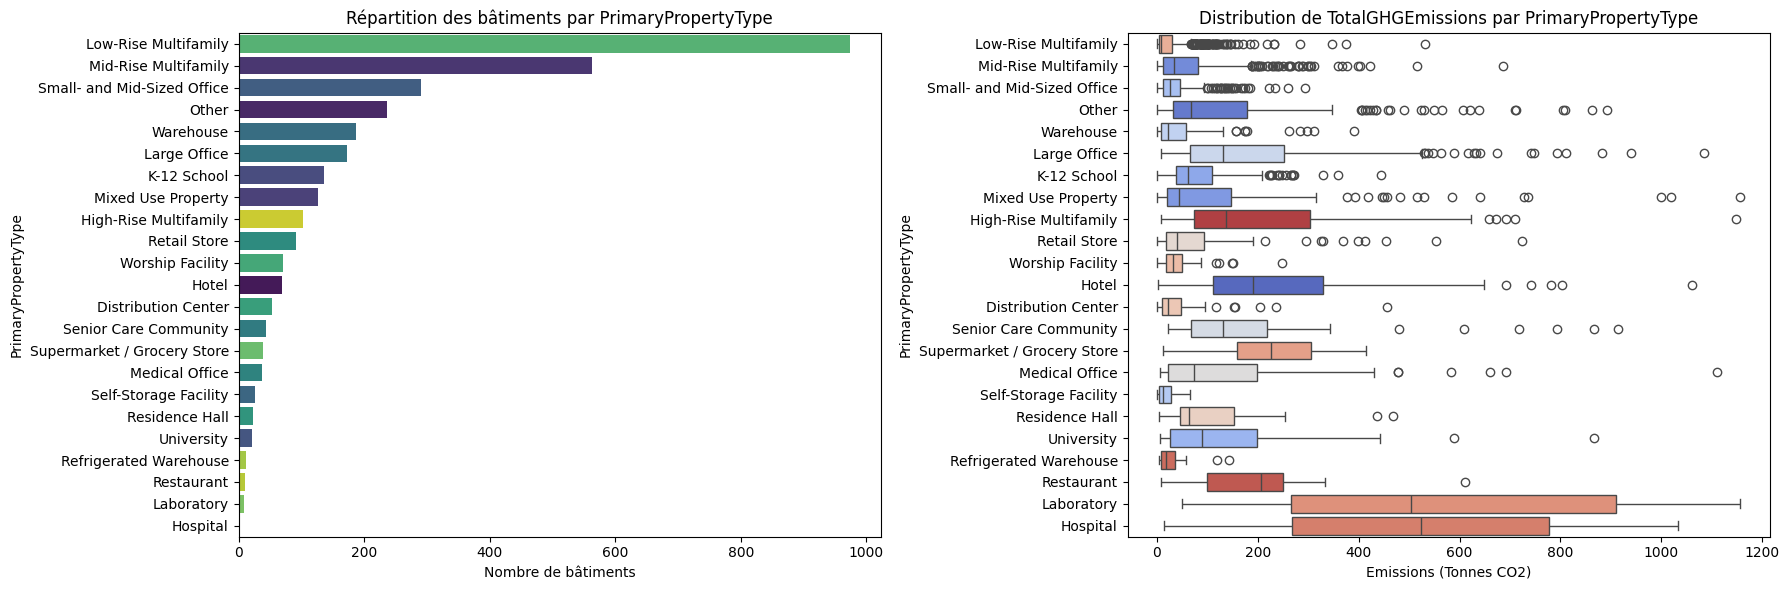

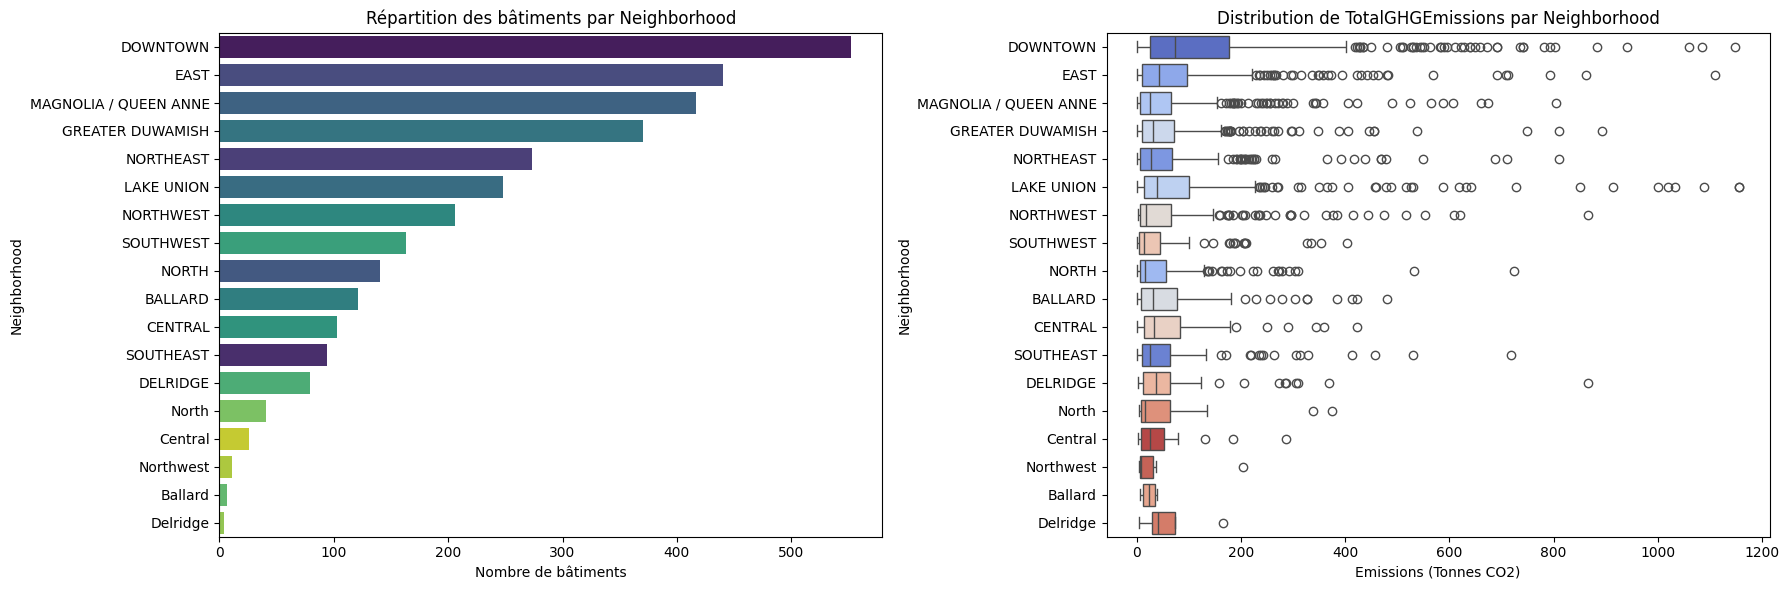

In [16]:
# 1. Identifier les colonnes catégorielles
df_cat = df_clean.select_dtypes(include=['object'])
target_col = 'TotalGHGEmissions'
features_cat = df_cat.columns

# 2. Boucle sur chaque feature catégorielle
for feature in features_cat:
    nb_categories = df_clean[feature].nunique()

    if nb_categories > 30:
        continue

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    # --- GRAPHIQUE 1 : Le Countplot ---
    sns.countplot(
        data=df_clean,
        y=feature,
        hue=feature,
        palette='viridis',
        order=df_clean[feature].value_counts().index,
        ax=axes[0]
    )
    axes[0].set_title(f"Répartition des bâtiments par {feature}")
    axes[0].set_xlabel("Nombre de bâtiments")

    # --- GRAPHIQUE 2 : Le Boxplot Catégoriel ---
    sns.boxplot(
        data=df_clean,
        y=feature,
        x=target_col,
        hue=feature,
        palette='coolwarm',
        order=df_clean[feature].value_counts().index,
        ax=axes[1]
    )
    axes[1].set_title(f"Distribution de {target_col} par {feature}")
    axes[1].set_xlabel("Emissions (Tonnes CO2)")

    plt.tight_layout()
    plt.show()

#### F8 Correction des doublons de case sensitivity pour 'Neighborhood'

Neighborhood
DOWNTOWN                 552
EAST                     440
MAGNOLIA / QUEEN ANNE    417
GREATER DUWAMISH         370
NORTHEAST                273
LAKE UNION               248
NORTHWEST                217
NORTH                    181
SOUTHWEST                163
CENTRAL                  129
BALLARD                  128
SOUTHEAST                 94
DELRIDGE                  83
Name: count, dtype: int64


/tmp/ipykernel_2128/2529401237.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Neighborhood'] = df_clean['Neighborhood'].str.upper().str.strip()


<Axes: xlabel='count', ylabel='Neighborhood'>

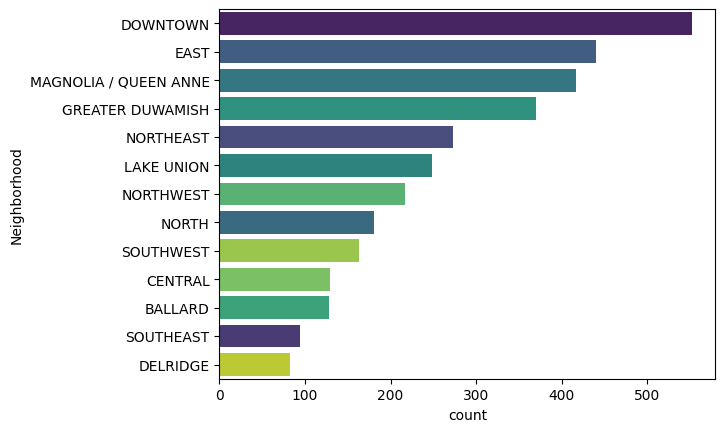

In [17]:
# On met tout en majuscules et on enlève les espaces invisibles avant/après
df_clean['Neighborhood'] = df_clean['Neighborhood'].str.upper().str.strip()
target_col = 'TotalGHGEmissions'
feature = 'Neighborhood'
# Vérifions le nouveau compte (vous verrez que la traîne a disparu !)
print(df_clean['Neighborhood'].value_counts())
sns.countplot(
    data=df_clean,
    y=feature,
    hue=feature,
    palette='viridis',
    order=df_clean[feature].value_counts().index,
)

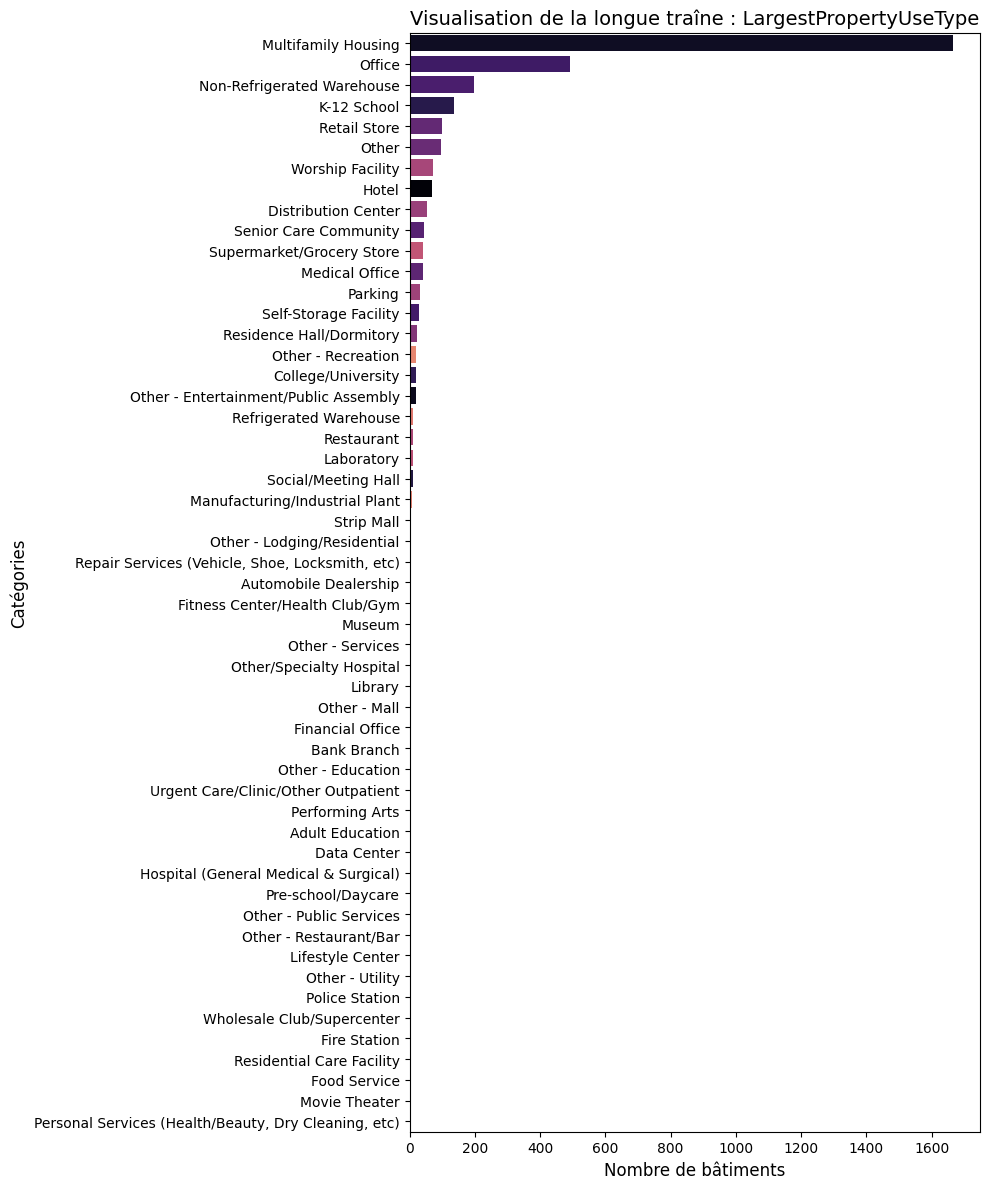

In [18]:
# 1. Isoler les variables textuelles
df_cat = df_clean.select_dtypes(include=['object'])

# 2. Garder UNIQUEMENT celles qui ont plus de 30 catégories
colonnes_longue_traine = [col for col in df_cat.columns if df_clean[col].nunique() > 30]

# 3. Tracer la distribution pour chacune d'elles
for feature in colonnes_longue_traine:
    # On crée une figure très haute (ex: 12 pouces) pour que le texte ne se chevauche pas
    plt.figure(figsize=(10, 12))

    # On récupère l'ordre exact du plus fréquent au moins fréquent
    ordre_categories = df_clean[feature].value_counts().index

    # Le Countplot horizontal
    sns.countplot(
        data=df_clean,
        y=feature,
        order=ordre_categories,
        hue=feature,
        legend=False,
        palette='magma' # Palette avec un beau dégradé pour souligner la traînée
    )

    plt.title(f"Visualisation de la longue traîne : {feature}", fontsize=14)
    plt.xlabel("Nombre de bâtiments", fontsize=12)
    plt.ylabel("Catégories", fontsize=12)

    plt.tight_layout()
    plt.show()

### Etude de la Target

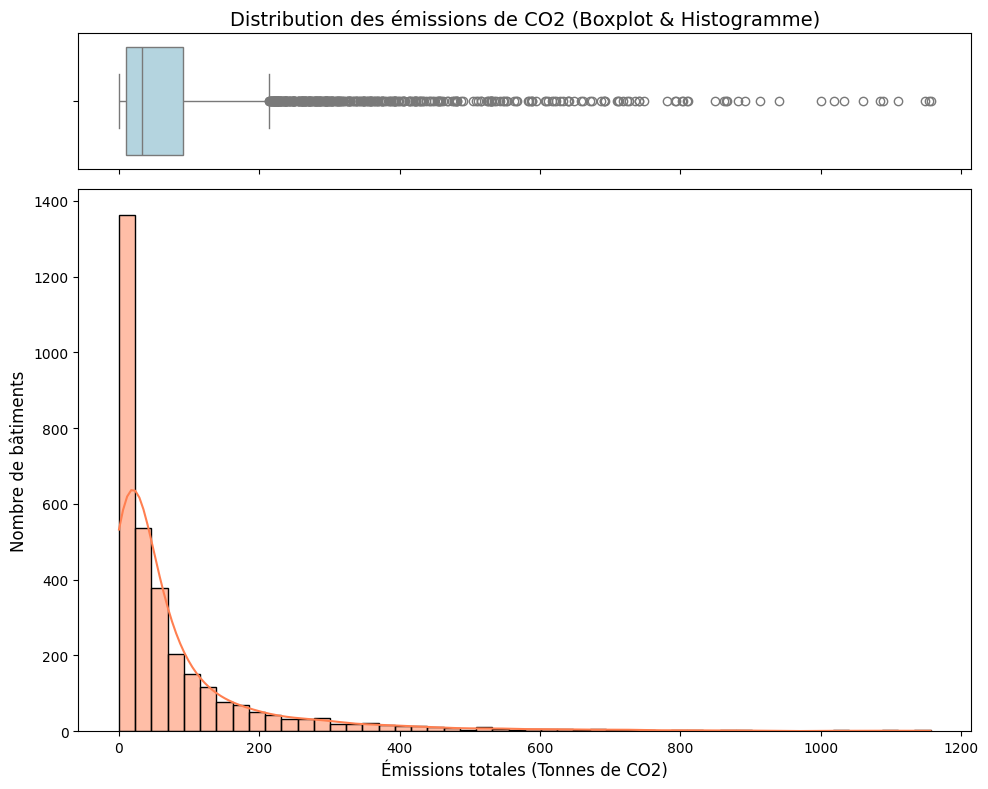

In [19]:
# Création d'une figure avec 2 lignes (une petite pour le boxplot, une grande pour l'histogramme)
fig, (ax_box, ax_hist) = plt.subplots(
    2, 1,
    figsize=(10, 8),
    sharex=True,
    gridspec_kw={"height_ratios": [1, 4]} # Le boxplot prend 1/5 de la hauteur, l'histo 4/5
)

# --- GRAPHIQUE 1 : Le Boxplot (En haut) ---
sns.boxplot(
    data=df_clean,
    x='TotalGHGEmissions',
    ax=ax_box,
    color='lightblue'
)
ax_box.set_title("Distribution des émissions de CO2 (Boxplot & Histogramme)", fontsize=14)
ax_box.set_xlabel('') # On cache le texte de l'axe X du boxplot pour ne pas faire doublon

# --- GRAPHIQUE 2 : L'Histogramme (En bas) ---
sns.histplot(
    data=df_clean,
    x='TotalGHGEmissions',
    bins=50,
    kde=True,
    ax=ax_hist,
    color='coral'
)
ax_hist.set_xlabel("Émissions totales (Tonnes de CO2)", fontsize=12)
ax_hist.set_ylabel("Nombre de bâtiments", fontsize=12)

# Affichage propre
plt.tight_layout()
plt.show()

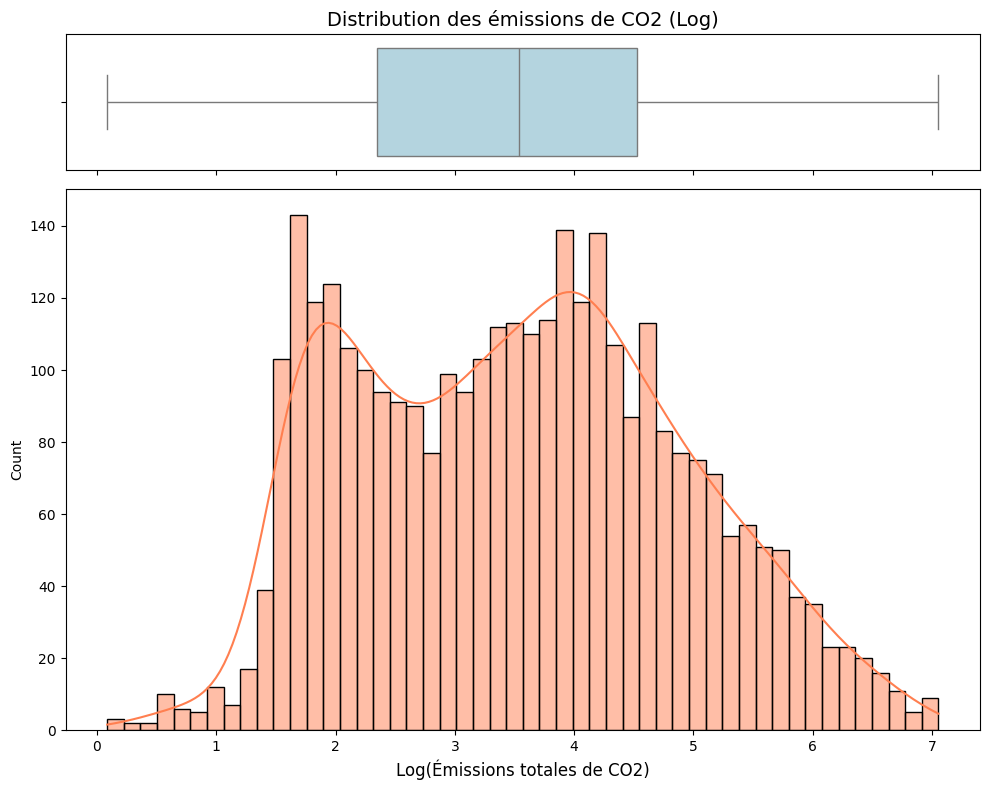

In [20]:
# Dans l'EDA : On calcule le log "à la volée" juste pour le graphique, sans modifier df_clean
fig, (ax_box, ax_hist) = plt.subplots(2, 1, figsize=(10, 8), sharex=True, gridspec_kw={"height_ratios": [1, 4]})

# On passe np.log1p() directement dans la donnée du graphique
sns.boxplot(x=np.log1p(df_clean['TotalGHGEmissions']), ax=ax_box, color='lightblue')
ax_box.set_title("Distribution des émissions de CO2 (Log)", fontsize=14)

sns.histplot(x=np.log1p(df_clean['TotalGHGEmissions']), bins=50, kde=True, ax=ax_hist, color='coral')
ax_hist.set_xlabel("Log(Émissions totales de CO2)", fontsize=12)

plt.tight_layout()
plt.show()

### Etude matrice de corrélation

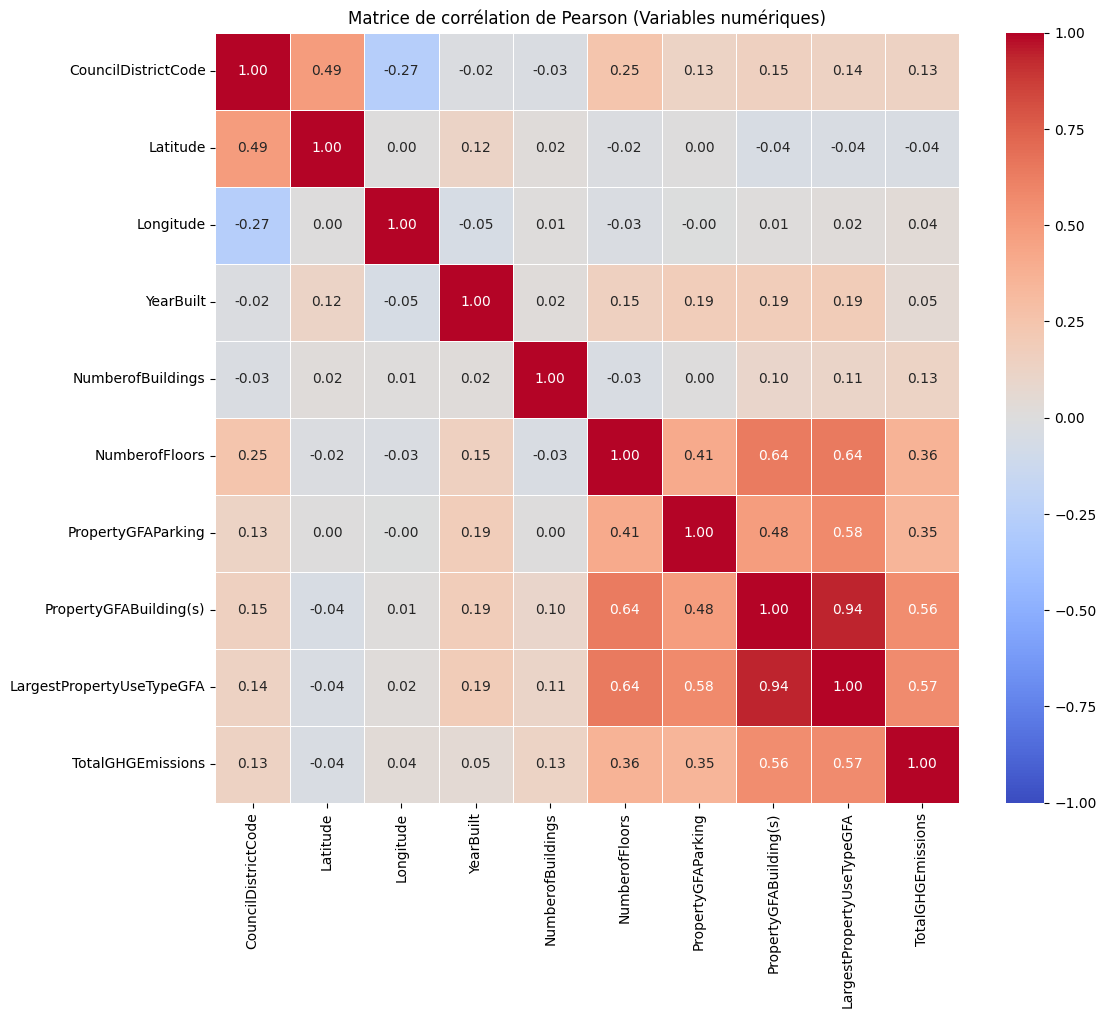

In [21]:
# On isole uniquement les variables numériques (incluant la nouvelle Target)
df_num = df_clean.select_dtypes(include=['float64', 'int64'])

# Calcul de la matrice de corrélation
matrice_corr = df_num.corr()

# Affichage graphique
plt.figure(figsize=(12, 10))
sns.heatmap(
    matrice_corr,
    annot=True,       # Affiche les chiffres dans les cases
    fmt=".2f",        # 2 chiffres après la virgule
    cmap="coolwarm",  # Rouge pour corrélation positive, bleu pour négative
    vmin=-1, vmax=1,  # L'échelle va de -1 à 1
    linewidths=0.5
)
plt.title("Matrice de corrélation de Pearson (Variables numériques)")
plt.show()

#### F9 Filtre sur la colinéarité

In [22]:
# Suppression de la variable redondante pour éviter la multicolinéarité
df_clean = df_clean.drop(columns=['LargestPropertyUseTypeGFA'])

### Vérification Finale

# Modélisation

### Import des modules

In [23]:
#Selection
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    cross_validate,
)
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.inspection import permutation_importance

#Preprocess
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler

#Modèles
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor


### Séparation des données

In [24]:
# On part du df_clean (qui a subi le nettoyage de casse et les filtres de base)
X_raw = df_clean.drop(columns=['TotalGHGEmissions'], errors='ignore')
y_raw = df_clean['TotalGHGEmissions']

X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=42
)

### Feature Engineering

In [25]:
top_8_categories = X_train_raw['LargestPropertyUseType'].value_counts().nlargest(8).index.tolist()

def apply_feature_engineering(X, y_raw, top_8):
    X_res = X.copy()

    # A. Transformation de la Target en Log (si elle est fournie)
    y_res = np.log1p(y_raw) if y_raw is not None else None

    # B. Le Regroupement Catégoriel
    X_res['LargestPropertyUseType_Grouped'] = X_res['LargestPropertyUseType'].apply(
        lambda x: x if x in top_8 else 'Other'
    )

    # C. Les Logs sur les variables numériques
    cols_to_log = [
        'NumberofBuildings',
        'PropertyGFAParking',
        'NumberofFloors',
        'PropertyGFABuilding(s)'
    ]
    for col in cols_to_log:
        if col in X_res.columns:
            X_res[f'{col}_log'] = np.log1p(X_res[col])

    # D. Nettoyage des anciennes colonnes (pour éviter les doublons et les textes bruts)
    cols_to_drop = [
        'LargestPropertyUseType',
        'LargestPropertyUseTypeGFA',
        'DefaultData',
        'index'
    ] + cols_to_log # On ajoute les anciennes colonnes non-loggées à la liste de suppression

    X_res = X_res.drop(columns=cols_to_drop, errors='ignore')

    # E. L'encodage One-Hot (get_dummies)
    colonnes_cat = [
        'Neighborhood',
        'PrimaryPropertyType',
        'BuildingType',
        'LargestPropertyUseType_Grouped'
    ]
    # On vérifie quelles colonnes sont présentes pour éviter les erreurs
    cols_presentes = [c for c in colonnes_cat if c in X_res.columns]
    X_res = pd.get_dummies(X_res, columns=cols_presentes, drop_first=True, dtype=int)

    return X_res, y_res

In [26]:
X_train, y_train = apply_feature_engineering(X_train_raw, y_train_raw, top_8_categories)
X_test, y_test = apply_feature_engineering(X_test_raw, y_test_raw, top_8_categories)

In [27]:
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

print(f"✅ Succès ! Dimensions de X_train : {X_train.shape}")
print(f"✅ Succès ! Dimensions de X_test  : {X_test.shape}")

✅ Succès ! Dimensions de X_train : (2636, 56)
✅ Succès ! Dimensions de X_test  : (659, 56)


In [28]:
X_train.info()
X_train.nunique()

<class 'pandas.core.frame.DataFrame'>
Index: 2636 entries, 3046 to 3235
Data columns (total 56 columns):
 #   Column                                                     Non-Null Count  Dtype  
---  ------                                                     --------------  -----  
 0   CouncilDistrictCode                                        2636 non-null   int64  
 1   Latitude                                                   2636 non-null   float64
 2   Longitude                                                  2636 non-null   float64
 3   YearBuilt                                                  2636 non-null   int64  
 4   NumberofBuildings_log                                      2636 non-null   float64
 5   PropertyGFAParking_log                                     2636 non-null   float64
 6   NumberofFloors_log                                         2636 non-null   float64
 7   PropertyGFABuilding(s)_log                                 2636 non-null   float64
 8   Neighborho

,0
CouncilDistrictCode,7
Latitude,2323
Longitude,2173
YearBuilt,112
NumberofBuildings_log,15
PropertyGFAParking_log,380
NumberofFloors_log,46
PropertyGFABuilding(s)_log,2512
Neighborhood_CENTRAL,2
Neighborhood_DELRIDGE,2


### Comparaison de différents modèles supervisés

In [29]:
# ==========================================
# 1. PRÉPARATION DU SCALING (NORMALISATION) -
# ==========================================
colonnes_continues = [
    'Latitude',
    'Longitude',
    'YearBuilt',
    'NumberofBuildings_log',
    'PropertyGFAParking_log',
    'NumberofFloors_log',
    'PropertyGFABuilding(s)_log'
]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), colonnes_continues)
    ],
    remainder='passthrough'
)

In [30]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
# ==========================================
# 2. LE REGISTRE DES MODÈLES ET MÉTADONNÉES
# ==========================================
modeles_registry = {
    'Dummy': {
        'nom_complet': 'Baseline Naïve',
        'famille': 'Baseline',
        'scaling_requis': False,
        'pipeline': DummyRegressor(strategy='mean'),
        'metriques': {} # Cet espace sera rempli par la boucle d'entraînement
    },
    'Ridge': {
        'nom_complet': 'Régression Linéaire Ridge',
        'famille': 'Linéaire',
        'scaling_requis': True,
        'pipeline': Pipeline([
            ('prep', preprocessor),
            ('model', Ridge(random_state=42))
        ]),
        'metriques': {}
    },
    'SVR': {
        'nom_complet': 'Support Vector Regressor',
        'famille': 'SVM',
        'scaling_requis': True,
        'pipeline': Pipeline([
            ('prep', preprocessor),
            ('model', SVR())
        ]),
        'metriques': {}
    },
    'RandomForest': {
        'nom_complet': 'Random Forest Regressor',
        'famille': 'Arbres de décision',
        'scaling_requis': False,
        'pipeline': RandomForestRegressor(random_state=42),
        'metriques': {}
    }
}

In [31]:
# ==========================================
# 3. ENTRAÎNEMENT ET ENREGISTREMENT
# ==========================================
for key, data in modeles_registry.items():
    print(f"Entraînement en cours : {data['nom_complet']}...")

    # On récupère l'algorithme à entraîner
    modele = data['pipeline']

    # Validation Croisée
    cv_scores = cross_validate(modele, X_train, y_train, cv=5, scoring='r2')

    # Entraînement final
    modele.fit(X_train, y_train)

    # Inférence
    y_pred_train = modele.predict(X_train)
    y_pred_test = modele.predict(X_test)

    # Stockage des résultats directement dans le registre du modèle
    data['metriques'] = {
        'R2_CV_Train': round(cv_scores['test_score'].mean(), 3),
        'R2_Train': round(r2_score(y_train, y_pred_train), 3),
        'R2_Test': round(r2_score(y_test, y_pred_test), 3),
        'MAE_Train': round(mean_absolute_error(y_train, y_pred_train), 3),
        'MAE_Test': round(mean_absolute_error(y_test, y_pred_test), 3),
        'RMSE_Train': round(np.sqrt(mean_squared_error(y_train, y_pred_train)), 3),
        'RMSE_Test': round(np.sqrt(mean_squared_error(y_test, y_pred_test)), 3)
    }

Entraînement en cours : Baseline Naïve...
Entraînement en cours : Régression Linéaire Ridge...
Entraînement en cours : Support Vector Regressor...
Entraînement en cours : Random Forest Regressor...


In [32]:
# ==========================================
# 4. GÉNÉRATION DU RAPPORT FINALE
# ==========================================
# On aplatit le dictionnaire pour en faire un beau tableau
lignes_rapport = []
for key, data in modeles_registry.items():
    ligne = {
        'ID_Modele': key,
        'Nom': data['nom_complet'],
        'Famille': data['famille']
    }
    # On fusionne les métadonnées avec les métriques calculées
    ligne.update(data['metriques'])
    lignes_rapport.append(ligne)

df_rapport = pd.DataFrame(lignes_rapport)

# Affichage du rapport
display(df_rapport)

# Exemple d'export pour votre futur rapport (décommentez pour utiliser)
# df_rapport.to_csv('rapport_modeles.csv', index=False)

,ID_Modele,Nom,Famille,R2_CV_Train,R2_Train,R2_Test,MAE_Train,MAE_Test,RMSE_Train,RMSE_Test
0,Dummy,Baseline Naïve,Baseline,-0.002,0.000,-0.002,1.140,1.154,1.362,1.377
1,Ridge,Régression Linéaire Ridge,Linéaire,0.524,0.551,0.554,0.735,0.749,0.912,0.919
2,SVR,Support Vector Regressor,SVM,0.533,0.589,0.539,0.652,0.719,0.873,0.934
3,RandomForest,Random Forest Regressor,Arbres de décision,0.561,0.939,0.553,0.253,0.703,0.336,0.920


### 1. Glossaire des Métriques Mathématiques

* **$R^2$ (Coefficient de détermination) :** C'est votre "pourcentage de réussite". Il mesure la capacité du modèle à expliquer la variance de la cible. Un score de 1 signifie une prédiction parfaite, tandis qu'un score de 0 équivaut à deviner bêtement la moyenne globale.
* **MAE (Mean Absolute Error) :** C'est l'erreur moyenne simple. Si la MAE est de 0.77, cela signifie qu'en moyenne, la prédiction du modèle s'éloigne de 0.77 "log-tonnes" de la réalité.
* **RMSE (Root Mean Squared Error) :** Cette métrique pénalise très fortement les grosses erreurs de prédiction via sa formule mathématique :
$$\text{RMSE} = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}$$


. Si votre RMSE est beaucoup plus élevée que la MAE, cela indique que le modèle se trompe parfois de manière monumentale sur certains bâtiments.

### 2. La Règle d'Or : Train vs Test

* **Le score "Train" (Apprentissage) :** Il indique si le modèle a bien compris l'information qu'on lui a donnée.
* **Le score "Test" (Généralisation) :** C'est le juge de paix. Il indique comment le modèle réagit face à des données qu'il n'a jamais vues. C'est le **seul** score qui importe pour évaluer la fiabilité finale.



### Optimisation et interprétation du modèle

#### Approche 1 : Corriger l'over-fitting & tuning des hyper-paramaters

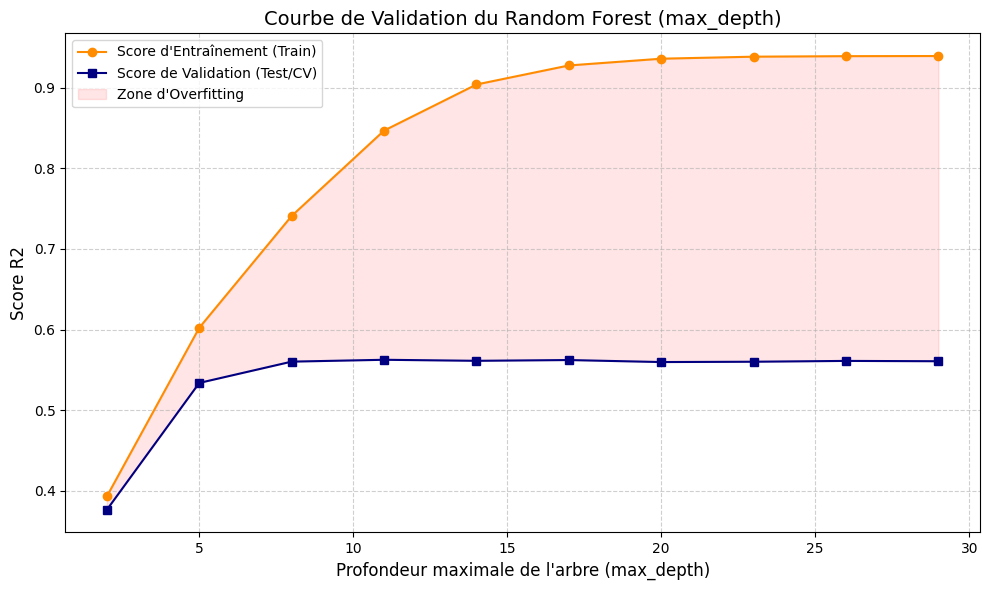

In [33]:
from sklearn.model_selection import validation_curve
# On teste différentes profondeurs d'arbres, de 2 (très simple) à 30 (très complexe)
param_range = np.arange(2, 32, 3)

train_scores, test_scores = validation_curve(
    RandomForestRegressor(random_state=42),
    X_train, y_train,
    param_name="max_depth",
    param_range=param_range,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

# Calcul des moyennes et écart-types
train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

# --- TRACÉ DU GRAPHIQUE ---
plt.figure(figsize=(10, 6))
plt.plot(param_range, train_mean, label="Score d'Entraînement (Train)", color="darkorange", marker='o')
plt.plot(param_range, test_mean, label="Score de Validation (Test/CV)", color="navy", marker='s')

# On remplit l'espace entre les courbes pour bien montrer la zone d'Overfitting
plt.fill_between(param_range, train_mean, test_mean, color="red", alpha=0.1, label="Zone d'Overfitting")

plt.title("Courbe de Validation du Random Forest (max_depth)", fontsize=14)
plt.xlabel("Profondeur maximale de l'arbre (max_depth)", fontsize=12)
plt.ylabel("Score R2", fontsize=12)
plt.legend(loc="best")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [34]:
from sklearn.model_selection import RandomizedSearchCV
# Définition de la grille de paramètres à explorer pour brider le modèle
param_distributions = {
    'max_depth': [5, 10, 15, 20],               # Empêche les arbres d'être trop profonds
    'min_samples_split': [2, 5, 10, 15],        # Bâtiments min. pour créer une nouvelle division
    'min_samples_leaf': [1, 2, 5, 10],          # Bâtiments min. pour valider une décision finale
    'max_features': ['sqrt', 'log2', 1.0]       # Limite le nb de variables regardées à chaque nœud
}

rf_base = RandomForestRegressor(random_state=42)

print("Recherche des meilleurs hyperparamètres en cours... (cela peut prendre une minute)")
rf_random = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_distributions,
    n_iter=20,          # Teste 20 combinaisons au hasard
    cv=5,               # Validation croisée sur 5 plis
    verbose=1,
    random_state=42,
    scoring='r2',
    n_jobs=-1
)

rf_random.fit(X_train, y_train)

print(f"Meilleurs paramètres trouvés : {rf_random.best_params_}")
meilleur_rf = rf_random.best_estimator_

Recherche des meilleurs hyperparamètres en cours... (cela peut prendre une minute)
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Meilleurs paramètres trouvés : {'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 20}


In [35]:
# A. Ajout du nouveau modèle optimisé dans le registre existant
modeles_registry['RandomForest_Opt'] = {
    'nom_complet': 'Random Forest Optimisé (Tuned)',
    'famille': 'Arbres de décision',
    'scaling_requis': False,
    'pipeline': meilleur_rf,
    'metriques': {}
}

# B. Calcul des métriques UNIQUEMENT pour le nouveau modèle
data = modeles_registry['RandomForest_Opt']
print(f"\nEntraînement final pour : {data['nom_complet']}...")

modele = data['pipeline']
cv_scores = cross_validate(modele, X_train, y_train, cv=5, scoring='r2')
modele.fit(X_train, y_train)

y_pred_train = modele.predict(X_train)
y_pred_test = modele.predict(X_test)

data['metriques'] = {
    'R2_CV_Train': round(cv_scores['test_score'].mean(), 3),
    'R2_Train': round(r2_score(y_train, y_pred_train), 3),
    'R2_Test': round(r2_score(y_test, y_pred_test), 3),
    'MAE_Train': round(mean_absolute_error(y_train, y_pred_train), 3),
    'MAE_Test': round(mean_absolute_error(y_test, y_pred_test), 3),
    'RMSE_Train': round(np.sqrt(mean_squared_error(y_train, y_pred_train)), 3),
    'RMSE_Test': round(np.sqrt(mean_squared_error(y_test, y_pred_test)), 3)
}

# C. Génération du Rapport Final
lignes_rapport = []
for key, modele_data in modeles_registry.items():
    ligne = {
        'ID_Modele': key,
        'Nom': modele_data['nom_complet'],
        'Famille': modele_data['famille']
    }
    ligne.update(modele_data['metriques'])
    lignes_rapport.append(ligne)

df_rapport_final = pd.DataFrame(lignes_rapport)

print("\n=== COMPARAISON DES PERFORMANCES (AVEC OPTIMISATION) ===")
display(df_rapport_final)


Entraînement final pour : Random Forest Optimisé (Tuned)...

=== COMPARAISON DES PERFORMANCES (AVEC OPTIMISATION) ===


,ID_Modele,Nom,Famille,R2_CV_Train,R2_Train,R2_Test,MAE_Train,MAE_Test,RMSE_Train,RMSE_Test
0,Dummy,Baseline Naïve,Baseline,-0.002,0.000,-0.002,1.140,1.154,1.362,1.377
1,Ridge,Régression Linéaire Ridge,Linéaire,0.524,0.551,0.554,0.735,0.749,0.912,0.919
2,SVR,Support Vector Regressor,SVM,0.533,0.589,0.539,0.652,0.719,0.873,0.934
3,RandomForest,Random Forest Regressor,Arbres de décision,0.561,0.939,0.553,0.253,0.703,0.336,0.920
4,RandomForest_Opt,Random Forest Optimisé (Tuned),Arbres de décision,0.568,0.849,0.563,0.411,0.713,0.528,0.910


#### Approche 2 - Features engineering d'optimisation

##### Etude des pires prédictions

=== LE TOP 5 DES PIRES PRÉDICTIONS ===


,Vraie_Valeur_Log,Prediction_Log,Erreur_Absolue
595,0.722706,4.062580,3.339874
2129,0.751416,3.897061,3.145644
1049,0.982078,3.894096,2.912017
74,1.961502,4.852693,2.891191
1950,2.204972,4.803160,2.598188



Calcul des valeurs SHAP en cours...

Autopsie SHAP pour le bâtiment (Index : 595)


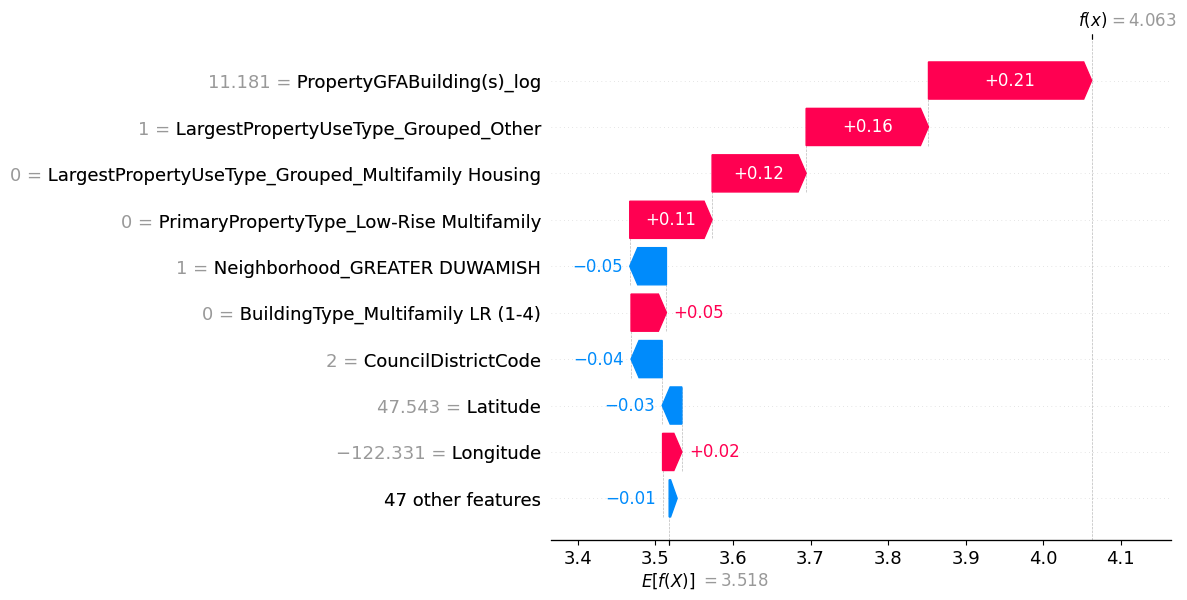

In [36]:
##### Analyse des Erreurs et SHAP
import shap

def analyser_et_expliquer_erreurs(modele, X_test, y_test):
    """
    Extrait les pires prédictions d'un modèle et génère l'autopsie SHAP
    pour le bâtiment le plus mal prédit.
    """
    # --- A. CALCUL ET EXTRACTION DES ERREURS ---
    y_pred_test = modele.predict(X_test)
    erreurs_absolues = np.abs(y_test - y_pred_test)

    # On regroupe tout dans un DataFrame d'analyse
    df_analyse = X_test.copy()
    df_analyse['Vraie_Valeur_Log'] = y_test
    df_analyse['Prediction_Log'] = y_pred_test
    df_analyse['Erreur_Absolue'] = erreurs_absolues

    # On isole les 5 bâtiments les plus mal prédits
    pires_erreurs = df_analyse.sort_values(by='Erreur_Absolue', ascending=False).head(5)
    print("=== LE TOP 5 DES PIRES PRÉDICTIONS ===")
    display(pires_erreurs[['Vraie_Valeur_Log', 'Prediction_Log', 'Erreur_Absolue']])

    # --- B. AUTOPSIE SHAP DU PIRE BÂTIMENT ---
    print("\nCalcul des valeurs SHAP en cours...")

    # TreeExplainer est parfait pour Random Forest et XGBoost
    explainer = shap.TreeExplainer(modele)
    shap_values = explainer(X_test)

    # On récupère la position du pire bâtiment dans la matrice X_test
    index_pire_batiment = pires_erreurs.index[0]
    position_matrice = X_test.index.get_loc(index_pire_batiment)

    # Génération du graphique Waterfall pour ce bâtiment précis
    print(f"\nAutopsie SHAP pour le bâtiment (Index : {index_pire_batiment})")
    shap.plots.waterfall(shap_values[position_matrice])


# ==========================================
# EXÉCUTION SUR LE NOUVEAU MODÈLE V2
# ==========================================
# Il suffit d'appeler la fonction avec vos nouvelles variables !
analyser_et_expliquer_erreurs(meilleur_rf, X_test, y_test)

In [37]:
colonnes_cibles = ['PrimaryPropertyType', 'LargestPropertyUseType', 'PropertyGFABuilding(s)','PropertyGFAParking']
display(df_clean.loc[[595], colonnes_cibles])

,PrimaryPropertyType,LargestPropertyUseType,PropertyGFABuilding(s),PropertyGFAParking
595,Distribution Center,Distribution Center,71718,0


##### Bilan de l'Analyse des Erreurs : Le syndrome de la "Boîte Vide"

**1. Le Constat**
Notre modèle a généré une erreur majeure sur un bâtiment précis : il a prédit une très forte émission de CO2 (environ 57 tonnes, soit 4.06 en log) pour un bâtiment qui n'en émet qu'environ 1 tonne (0.72 en log) dans la réalité.

**2. La Cause : L'aveuglement statistique**
L'explicabilité du modèle (SHAP) combinée à l'inspection de la donnée brute met en lumière une faille dans notre logique de réduction des dimensions :

* **Le piège de la taille :** Le modèle a réagi à une caractéristique évidente : la surface gigantesque du bâtiment (plus de 6 600 m²).
* **La perte d'information métier :** L'usage réel de ce bâtiment est *Distribution Center*. Cependant, comme nous avons utilisé une méthode de regroupement basée uniquement sur la **fréquence** (le Top 8), ce type d'usage a été fondu dans la catégorie fourre-tout **"Other"**.
* **Le résultat :** L'algorithme s'est retrouvé aveugle. Face à un bâtiment immense classé dans "Other", il a parié sur des émissions élevées. Il ne pouvait pas deviner qu'un centre de distribution est concrètement une immense "boîte vide" (très peu de chauffage, peu d'employés) avec une intensité énergétique dérisoire.

**3. La Solution : Le Feature Engineering Sémantique**
Les graphiques d'analyse exploratoire (distribution et boxplots) nous le confirment : regrouper les bâtiments uniquement par volume d'apparition écrase la réalité physique des bâtiments.

Pour corriger ce biais et améliorer la précision du modèle, nous devons passer d'un regroupement *statistique* à un regroupement *métier*. Nous allons abandonner le "Top 8" pour créer manuellement des **Super-Catégories** basées sur le profil énergétique. Par exemple, fusionner *Distribution Center*, *Refrigerated Warehouse* et *Non-Refrigerated Warehouse* en une seule grande famille "Logistique & Entrepôts". Le modèle pourra enfin apprendre la règle : *"Un entrepôt, même géant, émet peu de CO2."*


##### Correction par COUCHE - SÉMANTIQUE

In [38]:
print("PrimaryPropertyType uniques :", df_clean['PrimaryPropertyType'].unique().tolist())
print("\nLargestPropertyUseType uniques :", df_clean['LargestPropertyUseType'].unique().tolist())

PrimaryPropertyType uniques : ['Hotel', 'Other', 'Mid-Rise Multifamily', 'Mixed Use Property', 'K-12 School', 'University', 'Small- and Mid-Sized Office', 'Self-Storage Facility', 'Warehouse', 'Large Office', 'Senior Care Community', 'Medical Office', 'Retail Store', 'Residence Hall', 'Distribution Center', 'Worship Facility', 'Low-Rise Multifamily', 'Supermarket / Grocery Store', 'Laboratory', 'Hospital', 'Refrigerated Warehouse', 'Restaurant', 'High-Rise Multifamily']

LargestPropertyUseType uniques : ['Hotel', 'Police Station', 'Other - Entertainment/Public Assembly', 'Multifamily Housing', 'Library', 'Fitness Center/Health Club/Gym', 'Social/Meeting Hall', 'K-12 School', 'College/University', 'Automobile Dealership', 'Office', 'Self-Storage Facility', 'Non-Refrigerated Warehouse', 'Other - Mall', 'Senior Care Community', 'Medical Office', 'Retail Store', 'Other', 'Museum', 'Repair Services (Vehicle, Shoe, Locksmith, etc)', 'Other - Lodging/Residential', 'Residence Hall/Dormitory', 

In [39]:
# ==========================================
# FEATURE ENGINEERING : SUPER-CATÉGORIES MÉTIERS
# ==========================================

# 1. Définition des grandes familles logiques (exhaustif selon l'EDA)
categories_metier = {
    'Logistique_Entrepot': [
        'Distribution Center', 'Refrigerated Warehouse', 'Non-Refrigerated Warehouse',
        'Self-Storage Facility', 'Warehouse'
    ],
    'Residentiel': [
        'Multifamily Housing', 'Low-Rise Multifamily', 'Mid-Rise Multifamily',
        'High-Rise Multifamily', 'Residence Hall', 'Residence Hall/Dormitory',
        'Senior Care Community', 'Other - Lodging/Residential', 'Residential Care Facility'
    ],
    'Bureaux': [
        'Office', 'Small- and Mid-Sized Office', 'Large Office', 'Medical Office',
        'Financial Office', 'Bank Branch'
    ],
    'Education': [
        'K-12 School', 'University', 'College/University', 'Adult Education',
        'Pre-school/Daycare', 'Library', 'Other - Education'
    ],
    'Commerce_Detail': [
        'Retail Store', 'Supermarket/Grocery Store', 'Supermarket / Grocery Store',
        'Automobile Dealership', 'Wholesale Club/Supercenter', 'Strip Mall',
        'Other - Mall', 'Lifestyle Center'
    ],
    'Sante_Laboratoire': [
        'Hospital (General Medical & Surgical)', 'Hospital', 'Laboratory',
        'Urgent Care/Clinic/Other Outpatient', 'Other/Specialty Hospital'
    ],
    'Hotellerie_Loisirs': [
        'Hotel', 'Restaurant', 'Food Service', 'Other - Restaurant/Bar', 'Worship Facility',
        'Social/Meeting Hall', 'Museum', 'Fitness Center/Health Club/Gym',
        'Performing Arts', 'Movie Theater', 'Other - Recreation',
        'Other - Entertainment/Public Assembly'
    ],
    'Industrie_Tech': [
        'Data Center', 'Manufacturing/Industrial Plant', 'Other - Utility'
    ],
    'Services_Publics_Autres': [
        'Police Station', 'Fire Station', 'Repair Services (Vehicle, Shoe, Locksmith, etc)',
        'Personal Services (Health/Beauty, Dry Cleaning, etc)', 'Other - Services',
        'Other - Public Services', 'Mixed Use Property', 'Parking', 'Other'
    ]
}

# 2. Inversion du dictionnaire pour le map de Pandas
mapping_inverse = {}
for super_cat, sous_cats in categories_metier.items():
    for sous_cat in sous_cats:
        mapping_inverse[sous_cat] = super_cat

# 3. Application du mapping
df_clean['PrimaryPropertyType_Super'] = df_clean['PrimaryPropertyType'].map(mapping_inverse)
df_clean['LargestPropertyUseType_Super'] = df_clean['LargestPropertyUseType'].map(mapping_inverse)

# 4. Vérification post-mapping
print("Valeurs nulles générées :", df_clean['PrimaryPropertyType_Super'].isna().sum())

Valeurs nulles générées : 0


In [40]:
# 1. On applique le mapping sur nos deux colonnes catégorielles
X_raw_v2 = df_clean.drop(columns=['TotalGHGEmissions'], errors='ignore').copy()
y_raw_v2 = df_clean['TotalGHGEmissions'].copy()

X_raw_v2['PrimaryPropertyType'] = X_raw_v2['PrimaryPropertyType'].map(mapping_inverse).fillna('Autre_Mixte')
X_raw_v2['LargestPropertyUseType'] = X_raw_v2['LargestPropertyUseType'].map(mapping_inverse).fillna('Autre_Mixte')

# 2. Séparation Train / Test
X_train_raw_v2, X_test_raw_v2, y_train_raw_v2, y_test_raw_v2 = train_test_split(
    X_raw_v2, y_raw_v2, test_size=0.2, random_state=42
)

In [41]:
def apply_feature_engineering_v2(X, y_raw):
    X_res = X.copy()
    y_res = np.log1p(y_raw) if y_raw is not None else None

    # A. Les Logs sur les variables numériques
    cols_to_log = ['NumberofBuildings', 'PropertyGFAParking', 'NumberofFloors', 'PropertyGFABuilding(s)']
    for col in cols_to_log:
        if col in X_res.columns:
            X_res[f'{col}_log'] = np.log1p(X_res[col])

    # B. Nettoyage des anciennes colonnes
    cols_to_drop = ['LargestPropertyUseTypeGFA', 'DefaultData', 'index'] + cols_to_log
    X_res = X_res.drop(columns=cols_to_drop, errors='ignore')

    # C. L'encodage One-Hot (get_dummies)
    colonnes_cat = ['Neighborhood', 'PrimaryPropertyType', 'BuildingType', 'LargestPropertyUseType']
    cols_presentes = [c for c in colonnes_cat if c in X_res.columns]

    X_res = pd.get_dummies(X_res, columns=cols_presentes, drop_first=True, dtype=int)

    # D. SÉCURITÉ ABSOLUE : On supprime toutes les colonnes de texte résiduelles
    # (Cela va éliminer vos anciennes colonnes "_Super" qui ont causé le plantage)
    X_res = X_res.select_dtypes(exclude=['object'])

    return X_res, y_res

# Application
X_train_v2, y_train_v2 = apply_feature_engineering_v2(X_train_raw_v2, y_train_raw_v2)
X_test_v2, y_test_v2 = apply_feature_engineering_v2(X_test_raw_v2, y_test_raw_v2)

# Sécurité anti-plantage : on aligne les colonnes Train et Test
X_train_v2, X_test_v2 = X_train_v2.align(X_test_v2, join='left', axis=1, fill_value=0)

In [42]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

print("Entraînement du Random Forest avec les Super-Catégories...")

# On réutilise les meilleurs paramètres trouvés précédemment
rf_v2 = RandomForestRegressor(
    max_depth=15,
    max_features=1.0,
    min_samples_leaf=5,
    min_samples_split=2,
    random_state=42
)

rf_v2.fit(X_train_v2, y_train_v2)

# Prédiction
y_pred_test_v2 = rf_v2.predict(X_test_v2)
r2_final = r2_score(y_test_v2, y_pred_test_v2)

print(f"🎉 Nouveau Score R2 sur le jeu de test : {r2_final:.3f}")

Entraînement du Random Forest avec les Super-Catégories...
🎉 Nouveau Score R2 sur le jeu de test : 0.560


=== LE TOP 5 DES PIRES PRÉDICTIONS ===


,Vraie_Valeur_Log,Prediction_Log,Erreur_Absolue
595,0.722706,4.201545,3.478839
2129,0.751416,3.647202,2.895786
34,1.595339,4.376563,2.781224
1049,0.982078,3.626728,2.644649
391,1.530395,4.106134,2.575739



Calcul des valeurs SHAP en cours...

Autopsie SHAP pour le bâtiment (Index : 595)


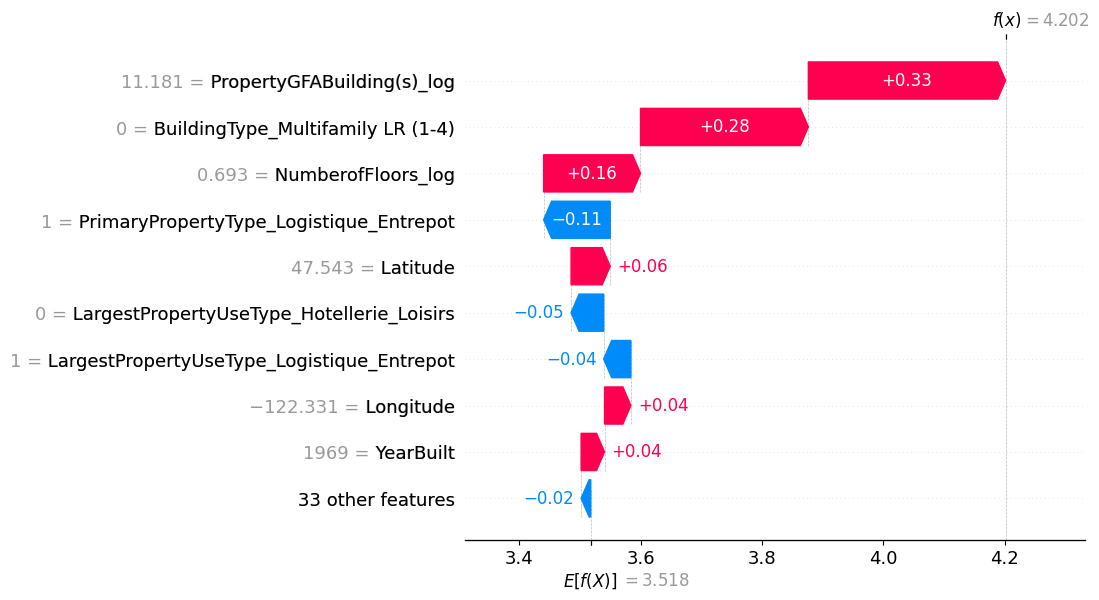

In [43]:
analyser_et_expliquer_erreurs(rf_v2, X_test_v2, y_test_v2)

In [44]:
display(df_clean.loc[[1049]])

,BuildingType,PrimaryPropertyType,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFAParking,PropertyGFABuilding(s),LargestPropertyUseType,DefaultData,TotalGHGEmissions,PrimaryPropertyType_Super,LargestPropertyUseType_Super
1049,NonResidential,Distribution Center,2,GREATER DUWAMISH,47.57382,-122.32672,1975,1.0,1,0,49950,Distribution Center,False,1.67,Logistique_Entrepot,Logistique_Entrepot


###### Bilan : L'impact mesuré des Super-Catégories Sémantiques (Stagnation du score global)

**1. Le Constat**
Après avoir remplacé notre sélection statistique par un regroupement sémantique rigoureux (*Super-Catégories* métiers pour unifier les entrepôts, les commerces et les résidences), nous avons relancé l'entraînement du modèle. Contre toute attente, le score $R^2$ global sur le jeu de test est resté pratiquement stable, oscillant autour de 0.560. D'un point de vue purement statistique, l'impact global a semblé insignifiant.

**2. La Cause : L'illusion de la métrique globale et l'angle mort physique**
Ce résultat apparemment neutre s'explique par deux facteurs fondamentaux :

* **La moyenne globale masque les corrections locales :** Le $R^2$ global évalue la performance de masse. Si les Super-Catégories ont bien éliminé des erreurs aberrantes sur des cas spécifiques (comme notre centre de distribution "boîte vide"), elles ne modifient pas drastiquement la variance de la grande majorité des bâtiments standards du dataset.
* **L'absence du facteur énergétique :** Sémantiquement, notre modèle sait désormais parfaitement ce qu'est un entrepôt ou une école. Cependant, il ignore toujours l'information la plus critique pour estimer du CO2 : *quelle est la source d'énergie utilisée pour le chauffage ?* Sans cette variable, un bâtiment géant bien classé sémantiquement reste une énigme mathématique pour l'algorithme.

**3. La Solution : Ne pas confondre structure et physique**
Cette étape, bien que neutre sur le score brut, n'a pas été inutile : elle a posé des fondations propres et indispensables pour l'interprétabilité du modèle. Elle nous a prouvé qu'un nettoyage sémantique garantit la **logique métier**, mais qu'il doit impérativement être complété par l'injection de **variables physiques** (comme la présence ou non de gaz et de vapeur) pour espérer briser le plafond de verre.

#### Implémentation de nouvelles features

In [45]:
colonnes_energie = [
    'PrimaryPropertyType', 'YearBuilt', 'PropertyGFABuilding(s)',
    'TotalGHGEmissions', 'Electricity(kBtu)', 'NaturalGas(kBtu)', 'SteamUse(kBtu)'
]

# On filtre par la surface exacte et l'année pour retrouver nos 3 pires prédictions
criteres = (
    ((building_consumption['PropertyGFABuilding(s)'] == 71718) & (building_consumption['YearBuilt'] == 1969)) |  # Le Centre de distribution (ex 595)
    ((building_consumption['PropertyGFABuilding(s)'] == 24152) & (building_consumption['YearBuilt'] == 1929)) |  # L'école (ex 2129)
    ((building_consumption['PropertyGFABuilding(s)'] == 110356) & (building_consumption['YearBuilt'] == 1955))   # Le Self-Storage (ex 34)
)

print("=== VÉRIFICATION DE L'HYPOTHÈSE ÉNERGÉTIQUE ===")
display(building_consumption.loc[criteres, colonnes_energie])

=== VÉRIFICATION DE L'HYPOTHÈSE ÉNERGÉTIQUE ===


,PrimaryPropertyType,YearBuilt,PropertyGFABuilding(s),TotalGHGEmissions,Electricity(kBtu),NaturalGas(kBtu),SteamUse(kBtu)
34,Self-Storage Facility,1955,110356,3.93,281265.0,37100.0,0.0
595,Distribution Center,1969,71718,1.06,151754.0,0.0,0.0
2129,K-12 School,1929,24152,1.12,161363.0,0.0,0.0


In [46]:
# 1. On crée une copie de df_clean pour recevoir nos nouvelles variables
df_clean_v3 = df_clean.copy()

# 2. On va chercher directement les données dans le df_raw d'origine en utilisant les index de df_clean
df_clean_v3['Has_NaturalGas'] = (building_consumption.loc[df_clean.index, 'NaturalGas(kBtu)'] > 0).astype(int)
df_clean_v3['Has_Steam'] = (building_consumption.loc[df_clean.index, 'SteamUse(kBtu)'] > 0).astype(int)

# 3. Vérification immédiate
print(f"Dimensions de df_clean_v3 : {df_clean_v3.shape}")
print("Nombre de bâtiments avec du gaz :", df_clean_v3['Has_NaturalGas'].sum())
print("Nombre de bâtiments avec de la vapeur :", df_clean_v3['Has_Steam'].sum())

Dimensions de df_clean_v3 : (3295, 18)
Nombre de bâtiments avec du gaz : 2059
Nombre de bâtiments avec de la vapeur : 114


In [47]:
# A. Séparation brute
X_raw_v3 = df_clean_v3.drop(columns=['TotalGHGEmissions'], errors='ignore')
y_raw_v3 = df_clean_v3['TotalGHGEmissions']

X_train_raw_3, X_test_raw_3, y_train_raw_3, y_test_raw_3 = train_test_split(
    X_raw_v3, y_raw_v3, test_size=0.2, random_state=42
)

# B. Feature Engineering (vos Super-Catégories + prise en compte automatique des nouvelles colonnes binaires)
X_train_3, y_train_3 = apply_feature_engineering_v2(X_train_raw_3, y_train_raw_3)
X_test_3, y_test_3 = apply_feature_engineering_v2(X_test_raw_3, y_test_raw_3)

# C. Alignement Train / Test
X_train_3, X_test_3 = X_train_3.align(X_test_3, join='left', axis=1, fill_value=0)

print(f"✅ X_3 prêt ! Nombre total de features : {X_train_3.shape[1]}")

✅ X_3 prêt ! Nombre total de features : 100


In [48]:
print("Entraînement du Random Forest avec l'info de source d'énergie")

# 1. Instanciation du modèle avec vos meilleurs paramètres
rf_v3 = RandomForestRegressor(
    max_depth=15,
    max_features=1.0,
    min_samples_leaf=5,
    min_samples_split=2,
    random_state=42
)

# 2. Fit sur le jeu d'entraînement v3 (qui intègre le gaz et la vapeur)
rf_v3.fit(X_train_3, y_train_3)

# 3. Prédiction sur le bon jeu de test (X_test_3 et non v2 !)
y_pred_test_v3 = rf_v3.predict(X_test_3)
r2_final = r2_score(y_test_3, y_pred_test_v3)

print(f"🎉 Nouveau Score R2 sur le jeu de test : {r2_final:.3f}")

Entraînement du Random Forest avec l'info de source d'énergie
🎉 Nouveau Score R2 sur le jeu de test : 0.766


=== LE TOP 5 DES PIRES PRÉDICTIONS ===


,Vraie_Valeur_Log,Prediction_Log,Erreur_Absolue
34,1.595339,5.425661,3.830322
2199,0.582216,3.681384,3.099168
1996,1.806648,4.170747,2.364099
3240,2.840831,5.156764,2.315933
595,0.722706,2.839662,2.116956



Calcul des valeurs SHAP en cours...

Autopsie SHAP pour le bâtiment (Index : 34)


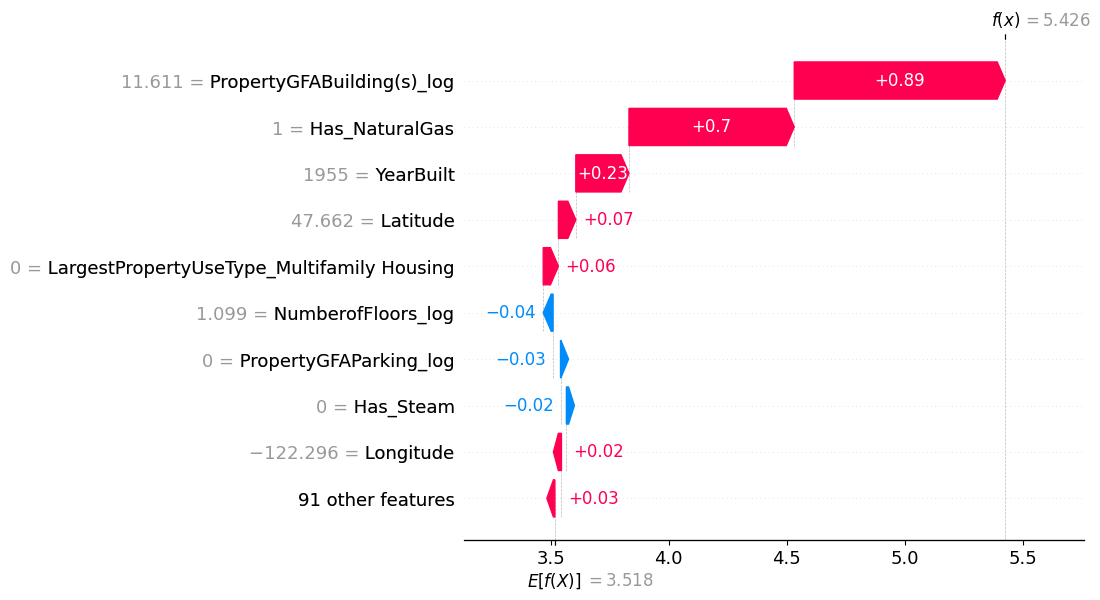

In [49]:
analyser_et_expliquer_erreurs(rf_v3, X_test_3, y_test_3)

In [50]:
# A. Ajout du nouveau modèle enrichi dans le registre existant
modeles_registry['RandomForest_Enrichi'] = {
    'nom_complet': 'Random Forest (Super-Cats + Énergie)',
    'famille': 'Arbres de décision',
    'scaling_requis': False,
    'pipeline': rf_v3,
    'metriques': {}
}

# B. Calcul des métriques UNIQUEMENT pour ce nouveau modèle (sur les datasets v3)
data = modeles_registry['RandomForest_Enrichi']
print(f"\nEntraînement et calcul final pour : {data['nom_complet']}...")

modele = data['pipeline']
cv_scores = cross_validate(modele, X_train_3, y_train_3, cv=5, scoring='r2')
modele.fit(X_train_3, y_train_3)

y_pred_train_v3 = modele.predict(X_train_3)
y_pred_test_v3 = modele.predict(X_test_3)

data['metriques'] = {
    'R2_CV_Train': round(cv_scores['test_score'].mean(), 3),
    'R2_Train': round(r2_score(y_train_3, y_pred_train_v3), 3),
    'R2_Test': round(r2_score(y_test_3, y_pred_test_v3), 3),
    'MAE_Train': round(mean_absolute_error(y_train_3, y_pred_train_v3), 3),
    'MAE_Test': round(mean_absolute_error(y_test_3, y_pred_test_v3), 3),
    'RMSE_Train': round(np.sqrt(mean_squared_error(y_train_3, y_pred_train_v3)), 3),
    'RMSE_Test': round(np.sqrt(mean_squared_error(y_test_3, y_pred_test_v3)), 3)
}

# C. Génération du Rapport Final comparant tous les modèles de l'historique
lignes_rapport = []
for key, modele_data in modeles_registry.items():
    ligne = {
        'ID_Modele': key,
        'Nom': modele_data['nom_complet'],
        'Famille': modele_data['famille']
    }
    ligne.update(modele_data['metriques'])
    lignes_rapport.append(ligne)

df_rapport_final = pd.DataFrame(lignes_rapport)

print("\n=== COMPARAISON FINALE DES PERFORMANCES (AVEC VARIABLES ÉNERGÉTIQUES) ===")
display(df_rapport_final)


Entraînement et calcul final pour : Random Forest (Super-Cats + Énergie)...

=== COMPARAISON FINALE DES PERFORMANCES (AVEC VARIABLES ÉNERGÉTIQUES) ===


,ID_Modele,Nom,Famille,R2_CV_Train,R2_Train,R2_Test,MAE_Train,MAE_Test,RMSE_Train,RMSE_Test
0,Dummy,Baseline Naïve,Baseline,-0.002,0.000,-0.002,1.140,1.154,1.362,1.377
1,Ridge,Régression Linéaire Ridge,Linéaire,0.524,0.551,0.554,0.735,0.749,0.912,0.919
2,SVR,Support Vector Regressor,SVM,0.533,0.589,0.539,0.652,0.719,0.873,0.934
3,RandomForest,Random Forest Regressor,Arbres de décision,0.561,0.939,0.553,0.253,0.703,0.336,0.920
4,RandomForest_Opt,Random Forest Optimisé (Tuned),Arbres de décision,0.568,0.849,0.563,0.411,0.713,0.528,0.910
5,RandomForest_Enrichi,Random Forest (Super-Cats + Énergie),Arbres de décision,0.750,0.876,0.766,0.342,0.485,0.479,0.665


### Bilan de l'Étape Finale : L'intégration des Indicateurs Énergétiques et l'Explosion des Performances ($R^2 = 0.766$)

**1. Le Constat**
En injectant les variables binaires de structure (`Has_NaturalGas` et `Has_Steam`) et en les combinant à nos Super-Catégories sémantiques, le modèle a franchi un cap radical. Le score $R^2$ global sur le jeu de test bondit de **0.560 à 0.766**.
Plus impressionnant encore : le modèle a totalement corrigé ses erreurs critiques sur le centre de distribution (index `595`) et l'école (index `2129`), qui ont disparu du sommet des pires prédictions. L'autopsie SHAP sur le nouveau pire cas persistant (le bâtiment `34`) met en lumière son talon d'Achille : le modèle se laisse tromper par sa surface démesurée et la présence de gaz (`Has_NaturalGas = 1`), surestimant ses émissions réelles.

**2. La Cause : La réconciliation entre la structure et la physique**
Jusqu'alors, le modèle tentait de deviner l'invisible en se basant uniquement sur la géométrie des bâtiments. En lui offrant l'information binaire de la source de chauffage sans provoquer de fuite de données (*data leakage*), nous avons comblé son angle mort fondamental :

* Un bâtiment 100 % électrique à Seattle émet des quantités infimes de CO2 grâce à l'hydroélectricité.
* Dès lors que le gaz ou la vapeur entrent en jeu, l'algorithme dispose de la véritable loi physique régissant l'intensité des émissions.

**3. La Solution et le Tableau Comparatif Final**
L'intégration de marqueurs physiques binaires non fuyants constitue la clé de voûte de la régression en milieu urbain. Le parcours itératif de notre Notebook trouve ici sa conclusion idéale, démontrant qu'aucun réglage d'hyperparamètres ne remplace une compréhension fine du domaine.

---

### 📊 Tableau Récapitulatif Final des Modèles

|index|ID\_Modele|Nom|Famille|R2\_CV\_Train|R2\_Train|R2\_Test|MAE\_Train|MAE\_Test|RMSE\_Train|RMSE\_Test|
|---|---|---|---|---|---|---|---|---|---|---|
|0|Dummy|Baseline Naïve|Baseline|-0\.002|0\.0|-0\.002|1\.14|1\.154|1\.362|1\.377|
|1|Ridge|Régression Linéaire Ridge|Linéaire|0\.524|0\.551|0\.554|0\.735|0\.749|0\.912|0\.919|
|2|SVR|Support Vector Regressor|SVM|0\.533|0\.589|0\.539|0\.652|0\.719|0\.873|0\.934|
|3|RandomForest|Random Forest Regressor|Arbres de décision|0\.561|0\.939|0\.553|0\.253|0\.703|0\.336|0\.92|
|4|RandomForest\_Opt|Random Forest Optimisé \(Tuned\)|Arbres de décision|0\.568|0\.849|0\.563|0\.411|0\.713|0\.528|0\.91|
|5|RandomForest\_Enrichi|Random Forest \(Super-Cats + Énergie\)|Arbres de décision|0\.75|0\.876|0\.766|0\.342|0\.485|0\.479|0\.665|